# Анализ и прогнозирование временных рядов на примере розничных продаж

## Загрузка данных

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import calendar
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller, kpss
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import find_peaks
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.fft import fft, fftfreq
import pywt

In [83]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Читаем датасет, беря за индексы колонку с датами

In [84]:
df = pd.read_csv('retail_sales_mock_data.csv',
parse_dates=True, index_col="Date")
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


## 2.1. Разведочный анализ данных (EDA)

### предварительный анализ временного ряда, визуализации

Рисуем графики датасета

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

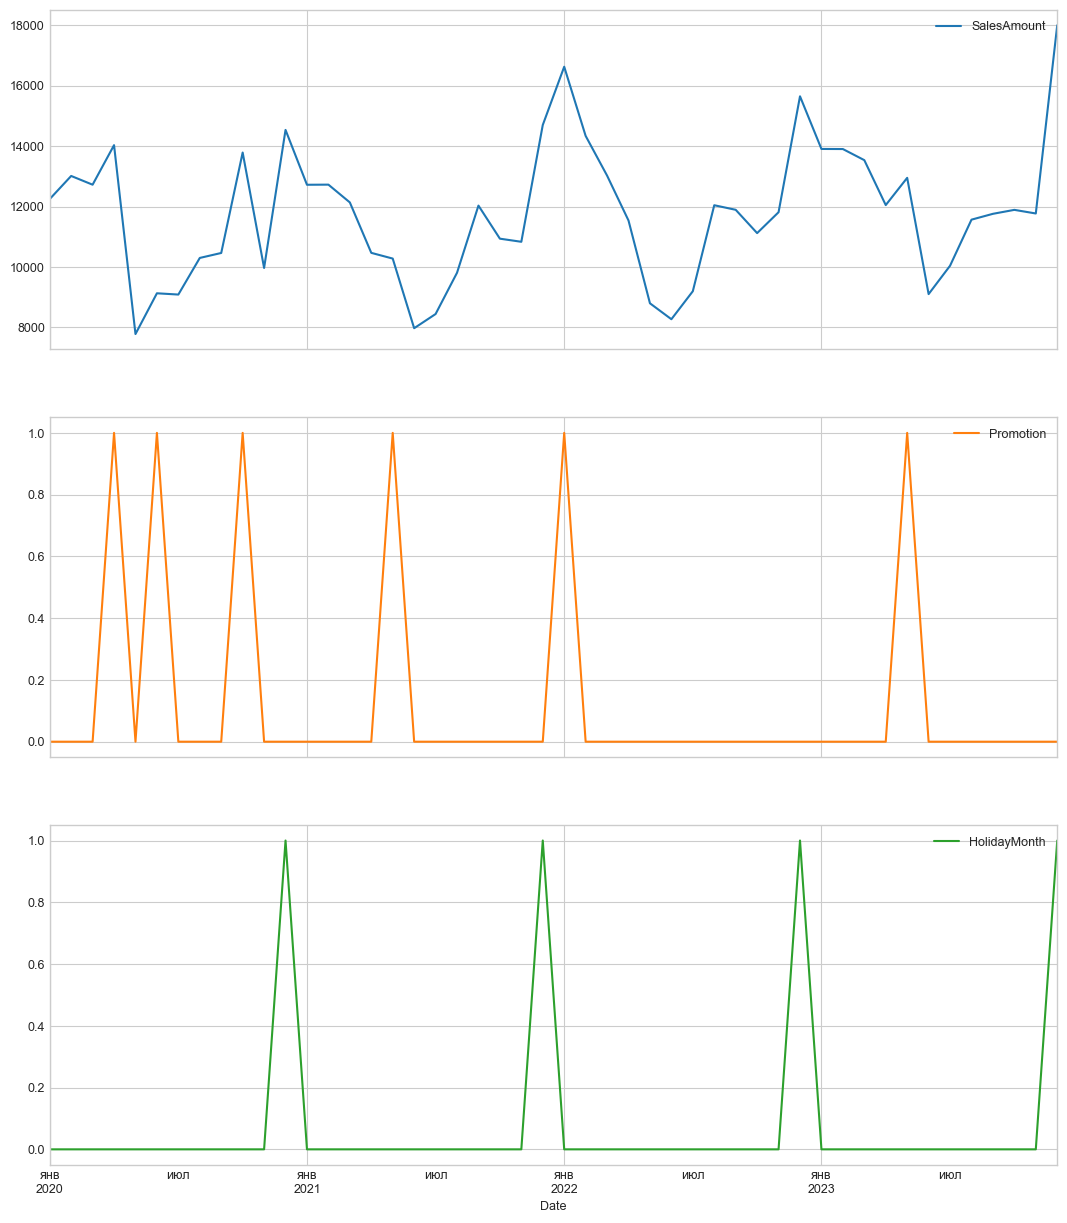

In [85]:
df.plot(subplots=True, figsize=(13,15))

Попытка обнаружить тренд через скользящее среднее и удаление возможного тренда

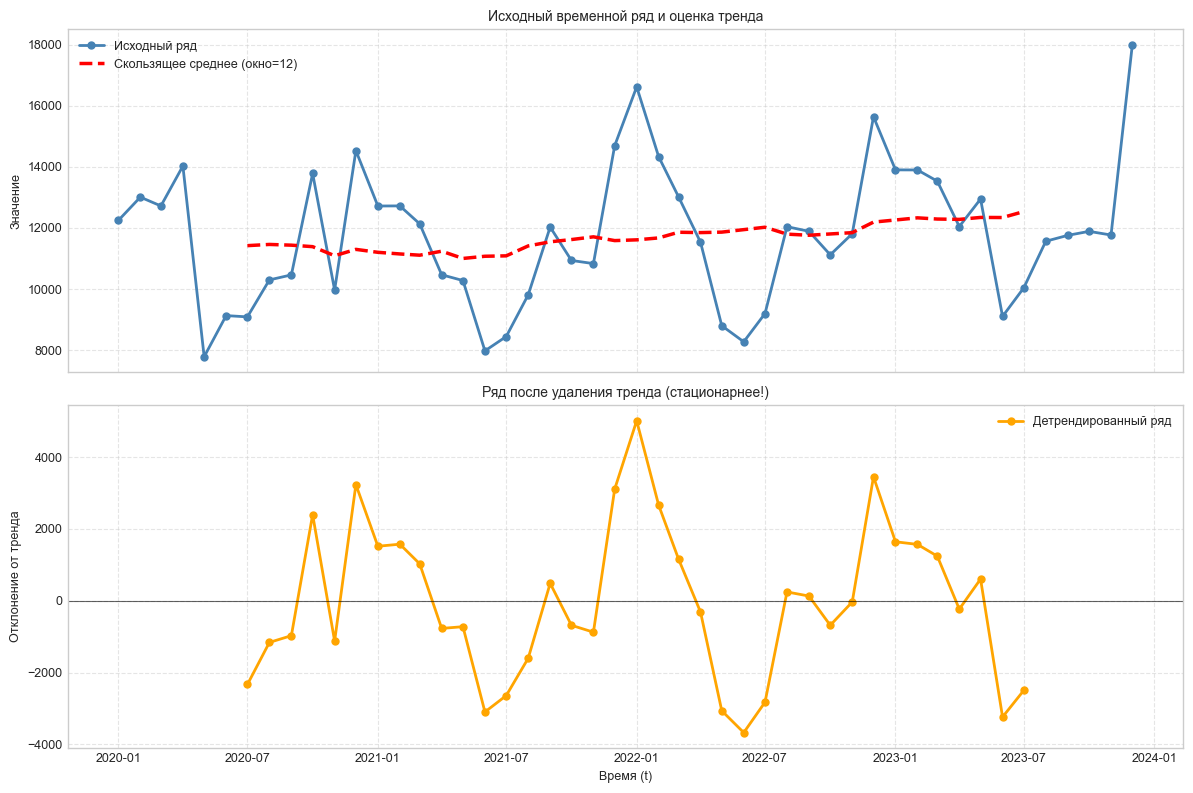

Статистики до и после удаления тренда:
Исходный ряд      → Среднее: 11688.91, Стд: 434.38
Детрендированный  → Среднее: -40.70, Стд: 2129.10


In [86]:
# Скользящее среднее (оценивает тренд)
window = 12
rolling_mean = df['SalesAmount'].rolling(window=window, center=True).mean()
dd = df['SalesAmount']
# Удаление тренда
detrended_data = df['SalesAmount'] - rolling_mean

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Верхний график: исходные данные + оценка тренда
axes[0].plot(df['SalesAmount'], marker='o', color='steelblue', label='Исходный ряд', linewidth=2, markersize=5)
axes[0].plot(rolling_mean, color='red', linestyle='--', linewidth=2.5, label=f'Скользящее среднее (окно={window})')
axes[0].set_ylabel('Значение')
axes[0].set_title('Исходный временной ряд и оценка тренда')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Нижний график: детрендированный ряд
axes[1].plot(detrended_data, marker='o', color='orange', linewidth=2, markersize=5, label='Детрендированный ряд')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.6)
axes[1].set_xlabel('Время (t)')
axes[1].set_ylabel('Отклонение от тренда')
axes[1].set_title('Ряд после удаления тренда (стационарнее!)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Проверим стационарность "на глаз" через статистики
print("Статистики до и после удаления тренда:")
print(f"Исходный ряд      → Среднее: {rolling_mean.mean():6.2f}, Стд: {rolling_mean.std():6.2f}")
print(f"Детрендированный  → Среднее: {detrended_data.mean():6.2f}, Стд: {detrended_data.std():6.2f}")

Создаем график автокорреляции

<Figure size 1500x300 with 0 Axes>

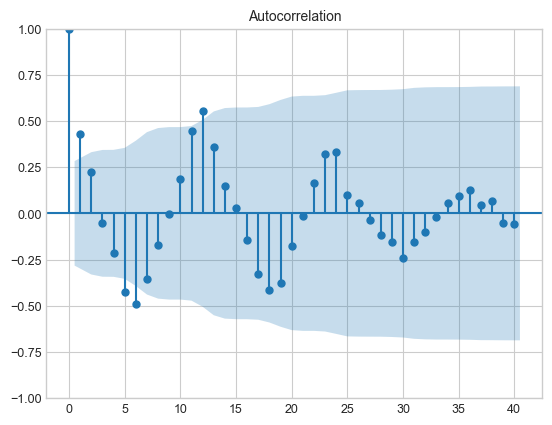

In [87]:
plt.figure(figsize=(15, 3))
sm.graphics.tsa.plot_acf(df['SalesAmount'].values.squeeze(), lags=40)
plt.show()

Попытка удалить тренд через дифференцирование

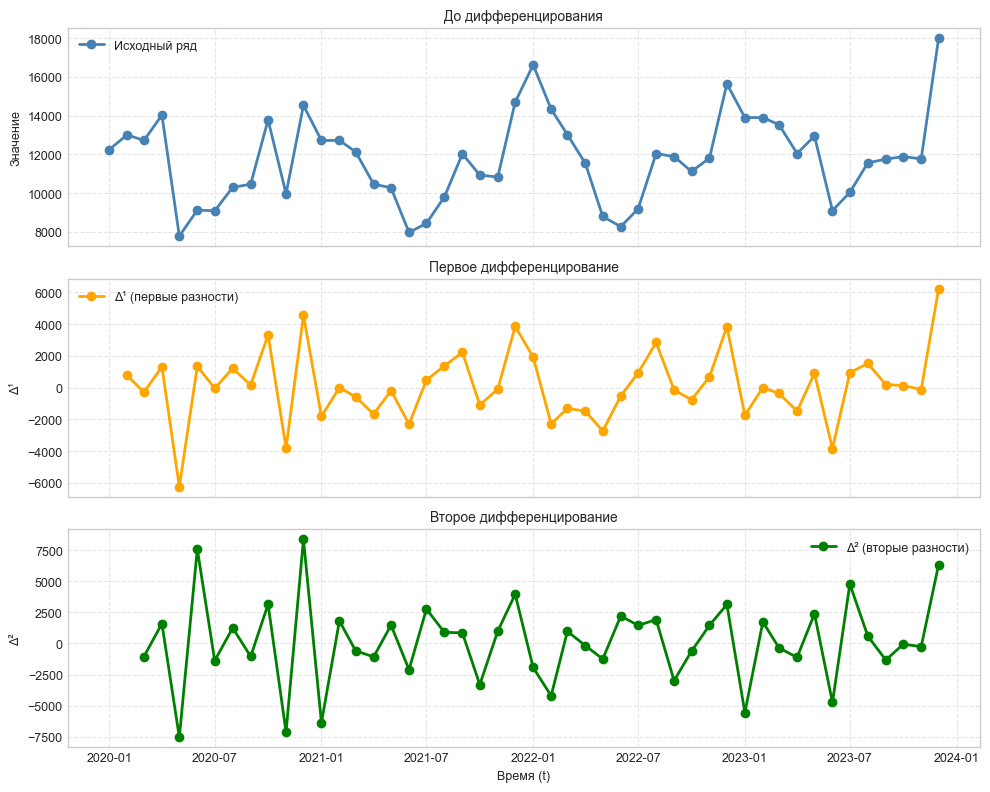

Исходный ряд:
  Среднее: 11768.54, Стд: 2257.54

После 1-го дифференцирования:
  Среднее: 122.30, Стд: 2254.14

После 2-го дифференцирования:
  Среднее: 118.76, Стд: 3424.61


In [88]:


# Первое дифференцирование — убирает тренд
diff1 = df['SalesAmount'].diff().dropna()

# Второе дифференцирование — если нужно (для квадратичного тренда)
diff2 = diff1.diff().dropna()

# Визуализация
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Исходные данные
axes[0].plot(df['SalesAmount'], marker='o', color='steelblue', linewidth=2, label='Исходный ряд')
axes[0].set_ylabel('Значение')
axes[0].set_title('До дифференцирования')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# После первого дифференцирования
axes[1].plot(diff1, marker='o', color='orange', linewidth=2, label='Δ¹ (первые разности)')
axes[1].set_ylabel('Δ¹')
axes[1].set_title('Первое дифференцирование')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

# После второго дифференцирования (если тренд нелинейный)
axes[2].plot(diff2, marker='o', color='green', linewidth=2, label='Δ² (вторые разности)')
axes[2].set_xlabel('Время (t)')
axes[2].set_ylabel('Δ²')
axes[2].set_title('Второе дифференцирование')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()

# Покажем статистики для наглядности
print("Исходный ряд:")
print(f"  Среднее: {dd.mean():.2f}, Стд: {dd.std():.2f}")
print("\nПосле 1-го дифференцирования:")
print(f"  Среднее: {diff1.mean():.2f}, Стд: {diff1.std():.2f}")
print("\nПосле 2-го дифференцирования:")
print(f"  Среднее: {diff2.mean():.2f}, Стд: {diff2.std():.2f}")

График средней розничной продажи за год

             SalesAmount  Promotion  HolidayMonth
Date                                             
2020-12-31  11422.250000   0.250000      0.083333
2021-12-31  11088.000000   0.083333      0.083333
2022-12-31  12025.333333   0.083333      0.083333
2023-12-31  12538.583333   0.083333      0.083333


<BarContainer object of 4 artists>

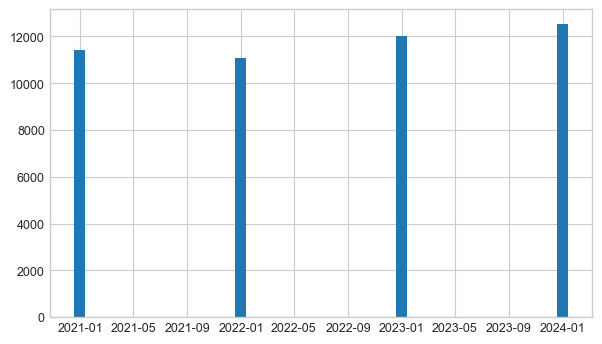

In [89]:
df_year = df.resample("YE").mean()
print(df_year)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_year.index, df_year.loc[:, "SalesAmount"], width=25, align='center')

График процентного соотношения между текущим и предыдущим месяцами

<BarContainer object of 48 artists>

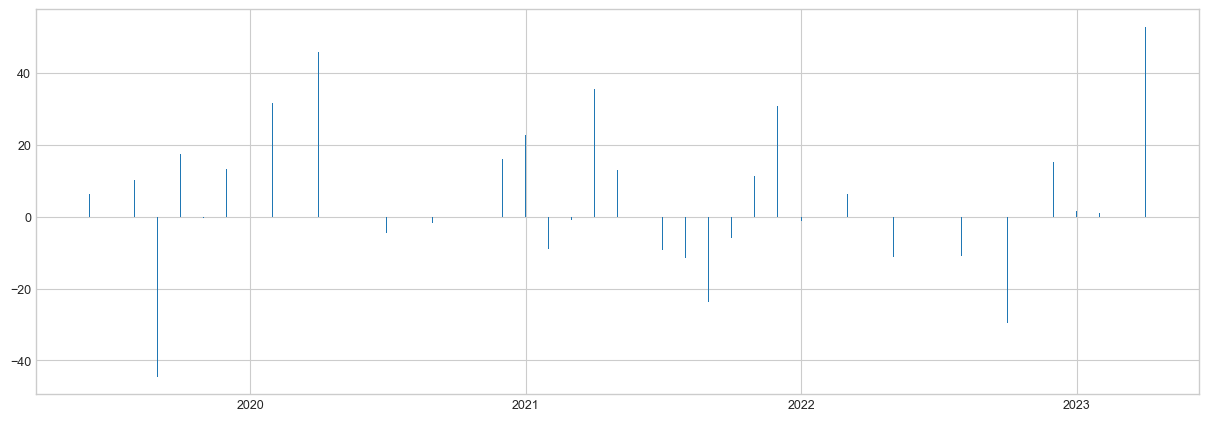

In [90]:
df.loc[:, 'pct_change'] = df.SalesAmount.pct_change() * 100

fig, ax = plt.subplots(figsize=(15, 5))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.bar(df.index, df.loc[:, 'pct_change'])

Диаграмма размаха для средних значений за год

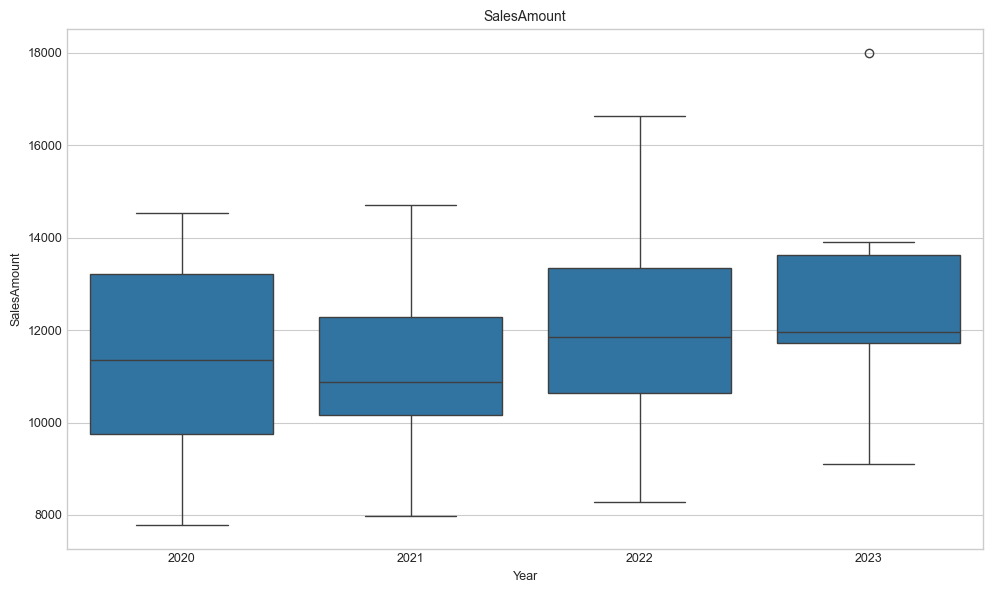

In [91]:
df['Year'] = df.index.year

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='Year', y='SalesAmount', ax=ax)
ax.set_xlabel("Year")
ax.set_title('SalesAmount')

plt.tight_layout()
plt.show()

In [92]:
df['month'] = df.index.month
df['year'] = df.index.year

all_month_year_df = pd.pivot_table(df, values="SalesAmount",
                                   index=["month"],
                                   columns=["year"],
                                   fill_value=0)
month_index = [month for month in calendar.month_abbr if month]

all_month_year_df = all_month_year_df.set_index([month_index])
all_month_year_df

year,2020,2021,2022,2023
янв,12248.0,12720.0,16623.0,13904.0
фев,13011.0,12724.0,14336.0,13901.0
мар,12722.0,12136.0,13023.0,13534.0
апр,14030.0,10468.0,11537.0,12048.0
май,7783.0,10279.0,8800.0,12949.0
июн,9131.0,7976.0,8273.0,9104.0
июл,9089.0,8445.0,9199.0,10042.0
авг,10300.0,9810.0,12043.0,11566.0
сен,10464.0,12031.0,11892.0,11759.0
окт,13786.0,10937.0,11121.0,11890.0


Тепловая карта 

Text(0.5, 1.0, 'SalesAmount')

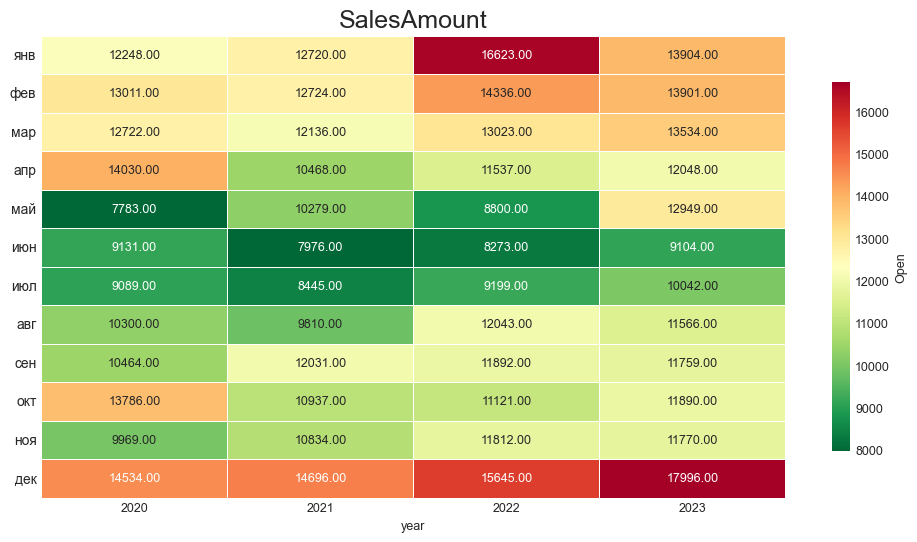

In [93]:
fig, ax = plt.subplots(figsize=(12,6))
ax = sns.heatmap(all_month_year_df, cmap='RdYlGn_r', robust=True,
                 fmt='.2f', annot=True, linewidths=.5, ax=ax,
                 cbar_kws={'shrink':.8, 'label':'Open'})

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title('SalesAmount', fontdict={'fontsize':18})

### декомпозицию ряда на компоненты

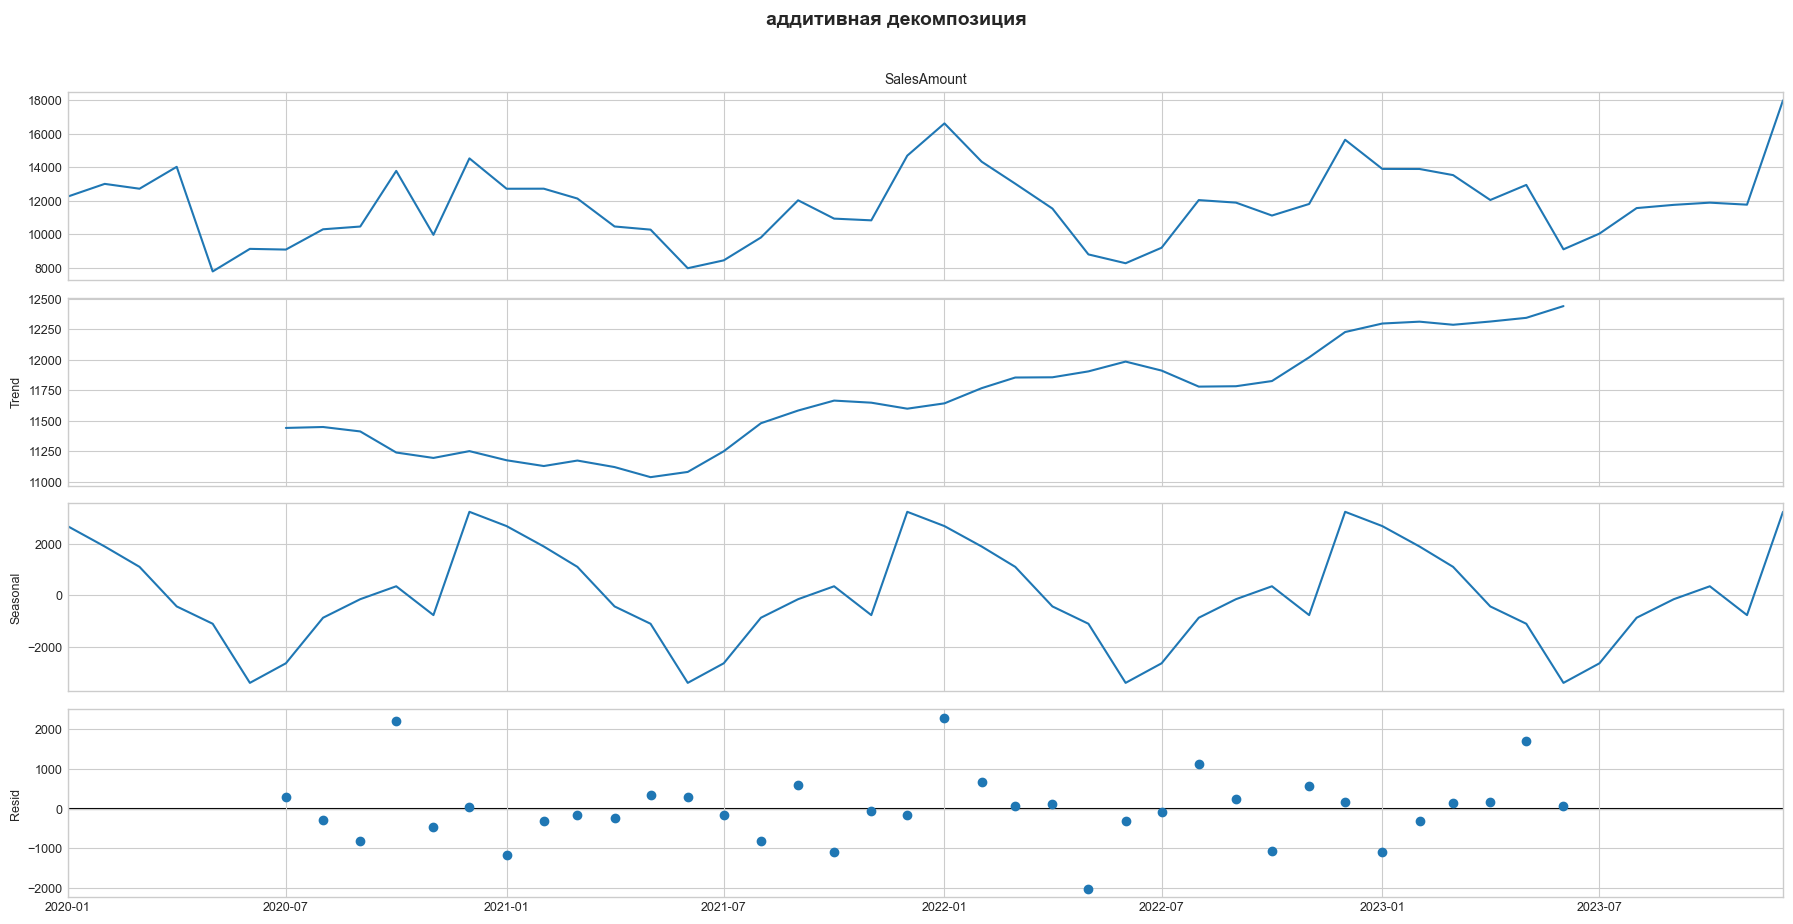

In [125]:
result = seasonal_decompose(df['SalesAmount'], model='additive', period=12)

fig2 = result.plot()
for ax in fig2.axes:
    ax.figure.set_size_inches(18, 9)
plt.suptitle('аддитивная декомпозиция',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

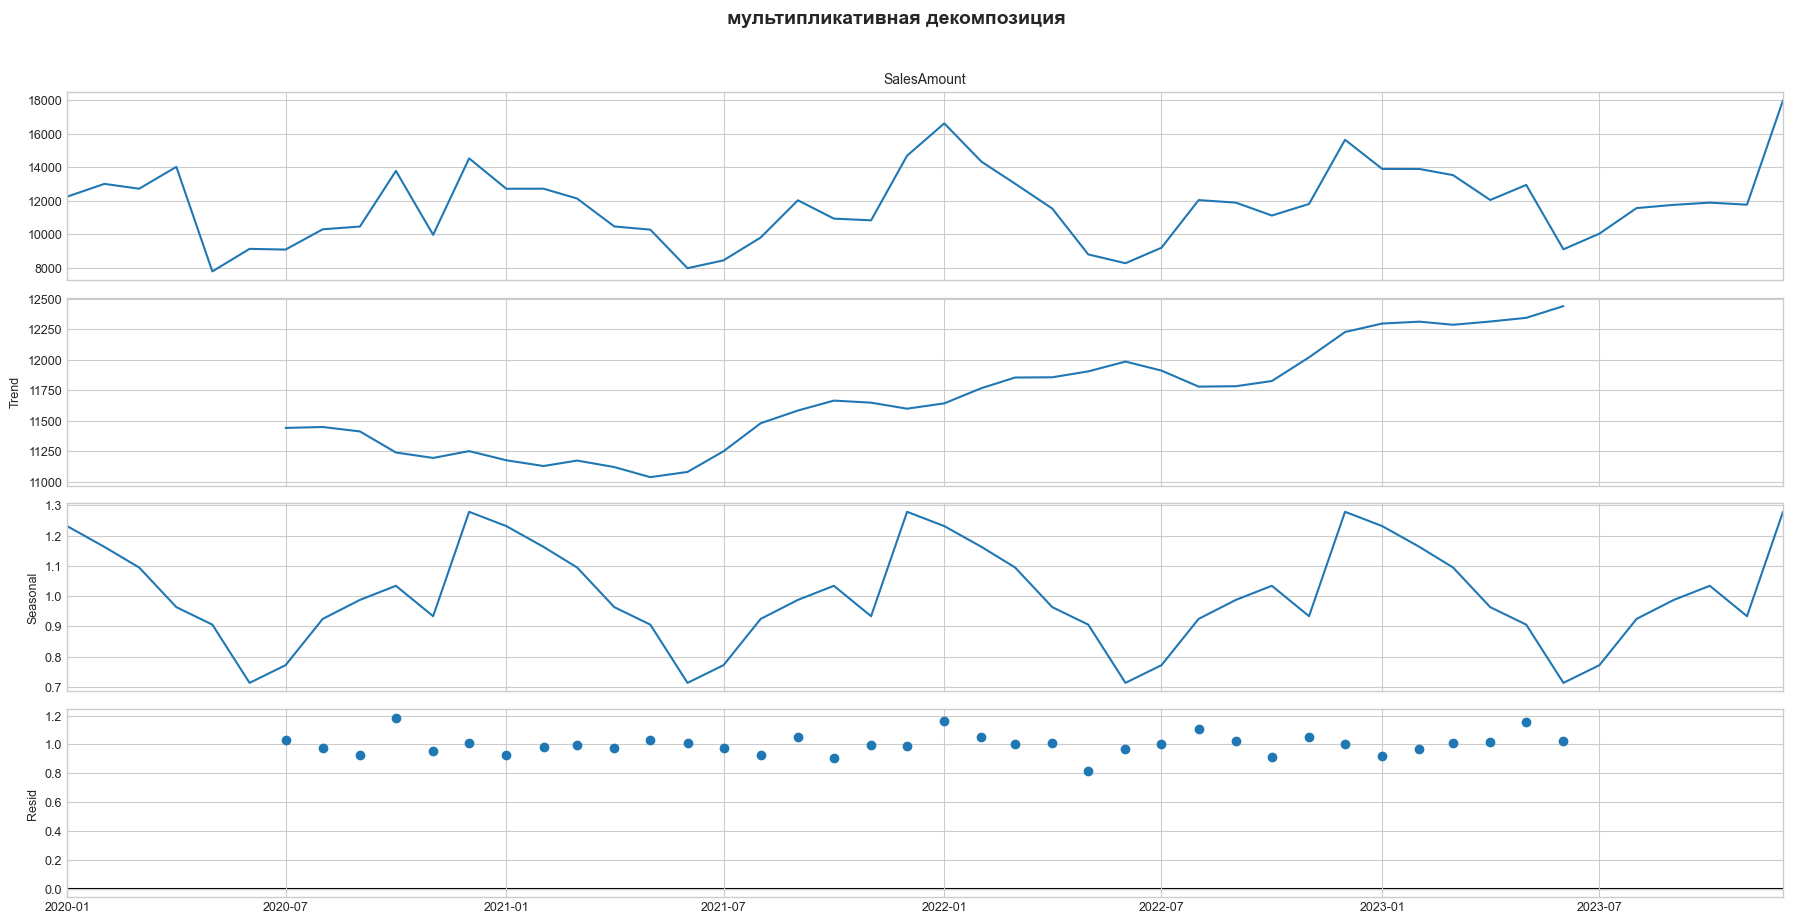

In [126]:
result = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)

fig2 = result.plot()
for ax in fig2.axes:
    ax.figure.set_size_inches(18, 9)
plt.suptitle('мультипликативная декомпозиция',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

STL-декомпозиция

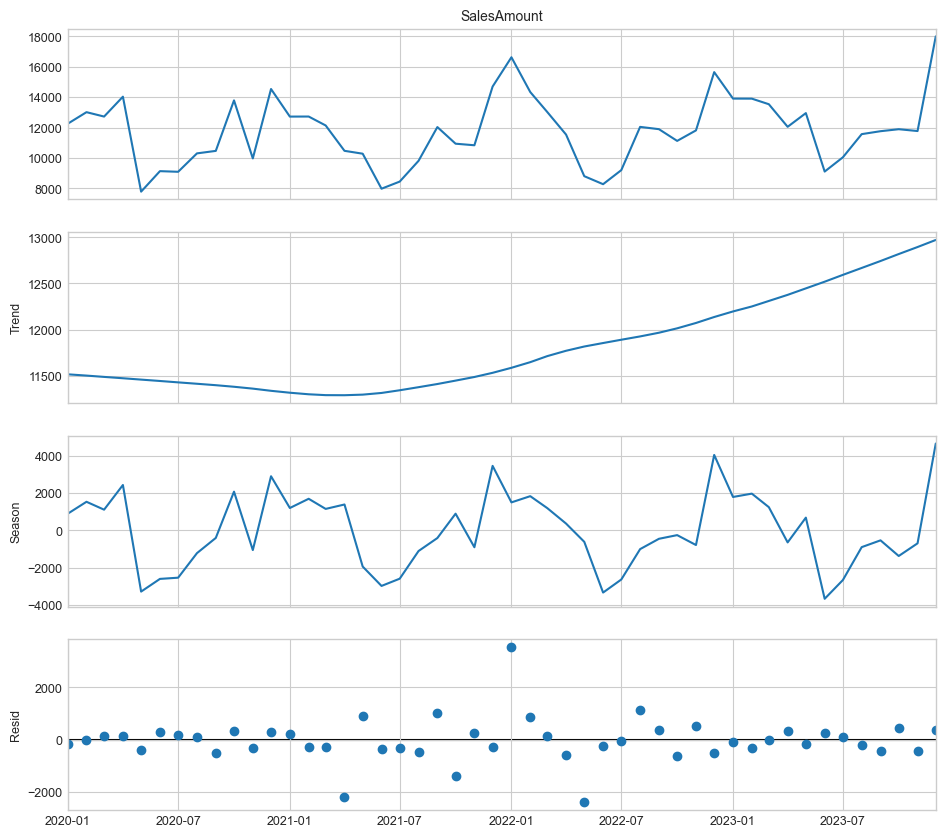

In [ ]:
stl = STL(df['SalesAmount'],
          period=12,
          seasonal=13,
          robust=True)
result = stl.fit()


fig = result.plot()
fig.set_size_inches((10, 9))
plt.show()

Используем FFT для поиска циклов

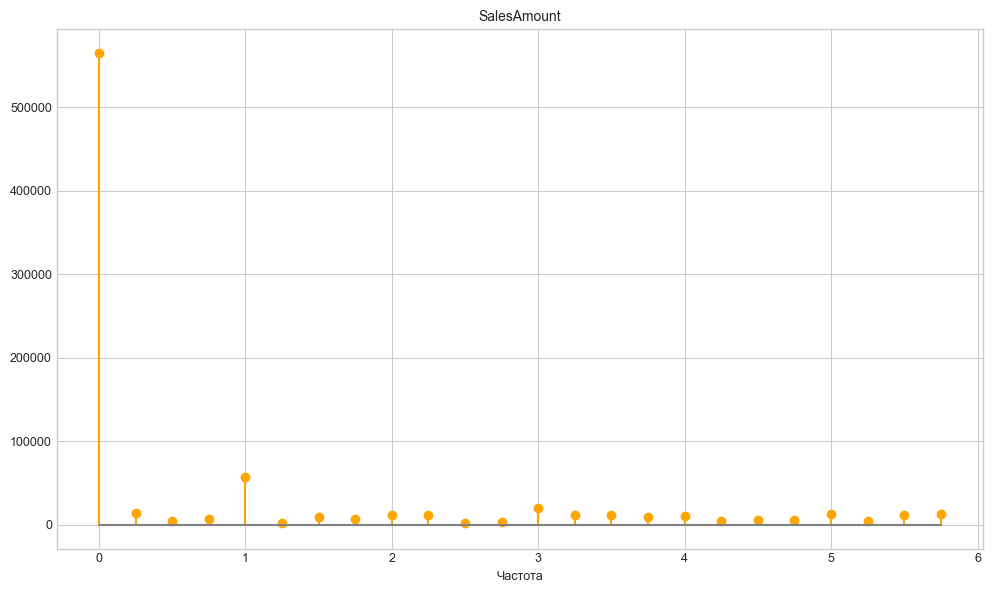

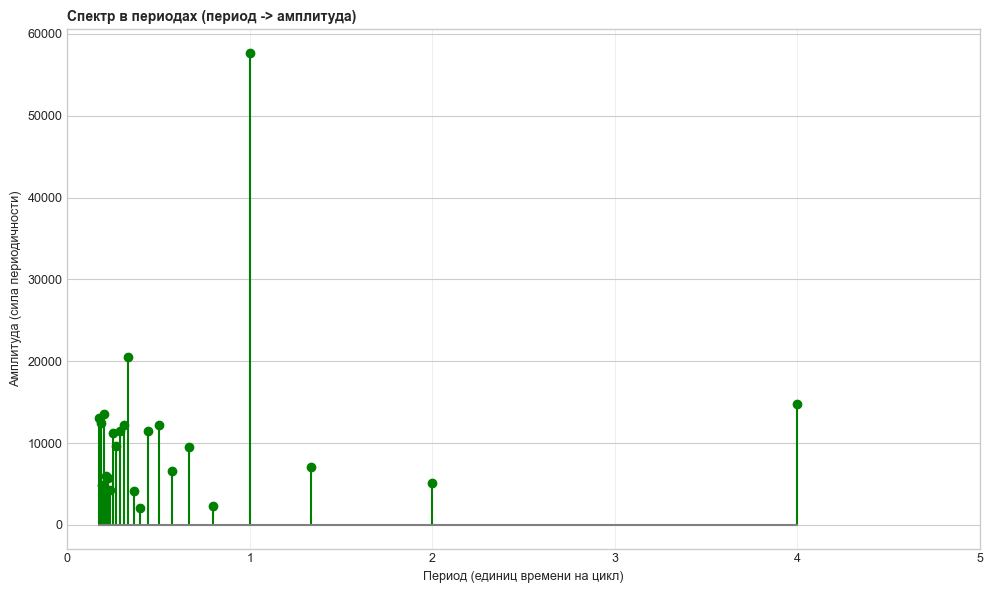

In [97]:

plt.style.use('seaborn-v0_8-whitegrid')

fft_values = fft(df['SalesAmount'])                    # комплексные коэффициенты
frequencies = fftfreq(len(df['SalesAmount']), 1/12)          # частоты (циклов за единицу времени)

# Берём только положительные частоты
power = np.abs(fft_values[:len(df['SalesAmount'])//2])      # АМПЛИТУДА (сила частоты)
freqs = frequencies[:len(df['SalesAmount'])//2]             # ЧАСТОТА (циклов за единицу времени)

fig, ax = plt.subplots(figsize=(10, 6))

ax.stem(freqs, power, linefmt='orange', markerfmt='o', basefmt='gray')
ax.set_xlabel("Частота")
ax.set_title('SalesAmount')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

periods = 1 / freqs[freqs > 0.01]  # переводим частоту в период
power_filtered = power[freqs > 0.01]

ax.stem(periods, power_filtered, linefmt='green', markerfmt='o', basefmt='gray')
ax.set_title('Спектр в периодах (период -> амплитуда)', fontweight='bold', loc='left')
ax.set_xlabel('Период (единиц времени на цикл)')
ax.set_ylabel('Амплитуда (сила периодичности)')
ax.set_xlim(0, 5)  # обрезаем для наглядности
ax.grid(True, alpha=0.3, axis='x')


plt.tight_layout()
plt.show()

In [128]:
print("Результаты Фурье-анализа:")
print(f"{'Частота':<10} {'Период':<10} {'Амплитуда':<10} {'Комментарий'}")
print("-" * 45)
# Находим 3 самых сильных пика (исключая нулевую частоту)
top_indices = np.argsort(power[1:])[::-1][:3] + 1  # +1 чтобы пропустить freq=0

for idx in top_indices:
    f = freqs[idx]
    amp = power[idx]
    period = 1/f if f > 0 else np.inf
    print(f"{f:<10.4f} {period:<10.1f} {amp:<10.2f} ")

Результаты Фурье-анализа:
Частота    Период     Амплитуда  Комментарий
---------------------------------------------
1.0000     1.0        57678.60   
3.0000     0.3        20504.20   
0.2500     4.0        14794.64   


In [99]:
!pip install PyWavelets

Выводим спектрограмму

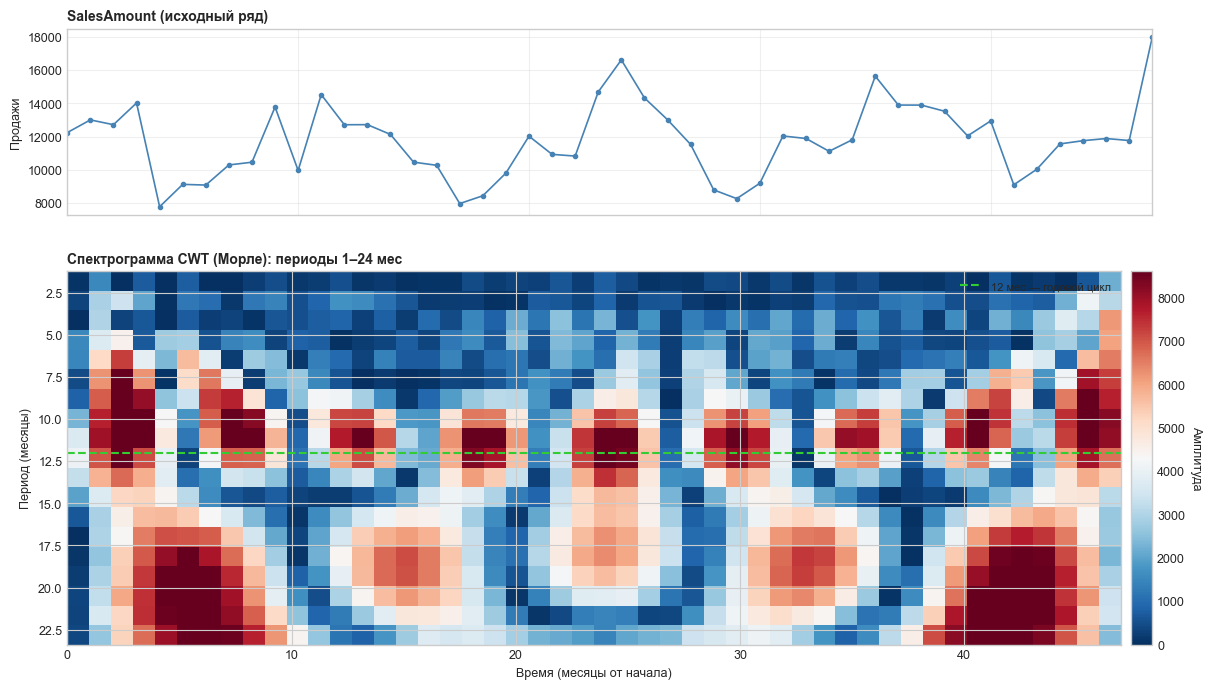

In [100]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9

signal = df['SalesAmount'].values
t = np.arange(len(signal))          # месяцы от начала ряда
sampling_period = 1                 # шаг ряда — 1 месяц

# === Непрерывное вейвлет-преобразование (вейвлет Морле) ===
wavelet = 'morl'
# Для ряда из 48 точек надёжно оцениваются периоды 1..48 мес:
# масштабы крупнее длины ряда попадают в "конус влияния" (искажения у краёв)
scales = np.arange(1, 49)
coefficients, frequencies = pywt.cwt(signal, scales, wavelet,
                                     sampling_period=sampling_period)

# === Подготовка спектрограммы ===
mask = frequencies > 0
periods = 1 / frequencies[mask]                     # период в месяцах
coefficients_abs = np.abs(coefficients[mask, :])
period_mask = (periods >= 1) & (periods <= 24)      # периоды до двух лет
periods_plot = periods[period_mask]
coefficients_plot = coefficients_abs[period_mask, :]

# === Визуализация: сигнал + спектрограмма ===
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                        gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.2})

axs[0].plot(t, signal, color='steelblue', linewidth=1.2, marker='o', ms=3)
axs[0].set_title('SalesAmount (исходный ряд)', fontweight='bold', loc='left')
axs[0].set_ylabel('Продажи')
axs[0].grid(True, alpha=0.3)

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="2%", pad=0.1)

im = axs[1].imshow(coefficients_plot,
                   extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
                   aspect='auto', cmap='RdBu_r',
                   vmin=0, vmax=np.percentile(coefficients_plot, 95))
axs[1].axhline(12, color='limegreen', linestyle='--', linewidth=1.5,
               label='12 мес — годовой цикл')
axs[1].legend(loc='upper right', fontsize=8)
axs[1].set_title('Спектрограмма CWT (Морле): периоды 1–24 мес',
                 fontweight='bold', loc='left')
axs[1].set_ylabel('Период (месяцы)')
axs[1].set_xlabel('Время (месяцы от начала)')

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Амплитуда', rotation=270, labelpad=12, fontsize=9)

plt.show()

# сохраняем результат для следующих ячеек
wavelet_results = {
    't': t,
    'frequencies': frequencies[mask],
    'periods': periods,
    'periods_plot': periods_plot,
    'coefficients_plot': coefficients_plot,
}


In [101]:
# === Поиск доминирующих циклов в доступном диапазоне (1–24 мес) ===
def find_dominant_cycles(periods, coefficients, top_n=5, min_distance=2):
    """Возвращает список доминирующих периодов (в месяцах), отсортированных по силе."""
    mean_power = np.mean(coefficients, axis=1)
    top_idx = np.argsort(mean_power)[::-1]

    results = []
    for idx in top_idx:
        if len(results) >= top_n:
            break
        period = periods[idx]
        # пропускаем периоды, близкие к уже выбранным
        if not any(abs(period - r) < min_distance for r in results):
            results.append(round(float(period), 1))
    return results


dominant_cycles = find_dominant_cycles(wavelet_results['periods_plot'],
                                       wavelet_results['coefficients_plot'],
                                       top_n=5)

comments = {1: 'помесячная вариативность / шум',
            3: 'квартальный цикл',
            4: 'квартальный цикл',
            6: 'полугодовой цикл',
            12: 'ГОДОВАЯ СЕЗОННОСТЬ — основной цикл розничных продаж'}


def cycle_comment(period):
    best = min(comments, key=lambda k: abs(k - period))
    return comments[best] if abs(best - period) <= 1 else 'без типовой интерпретации'


print("Доминирующие циклы в данных (по данным вейвлет-анализа):")
for i, period in enumerate(dominant_cycles, 1):
    print(f"  {i}. ~{period:>5} мес — {cycle_comment(period)}")


Доминирующие циклы в данных (по данным вейвлет-анализа):
  1. ~ 11.1 мес — ГОДОВАЯ СЕЗОННОСТЬ — основной цикл розничных продаж
  2. ~ 19.7 мес — без типовой интерпретации
  3. ~ 23.4 мес — без типовой интерпретации
  4. ~ 17.2 мес — без типовой интерпретации
  5. ~  8.6 мес — без типовой интерпретации


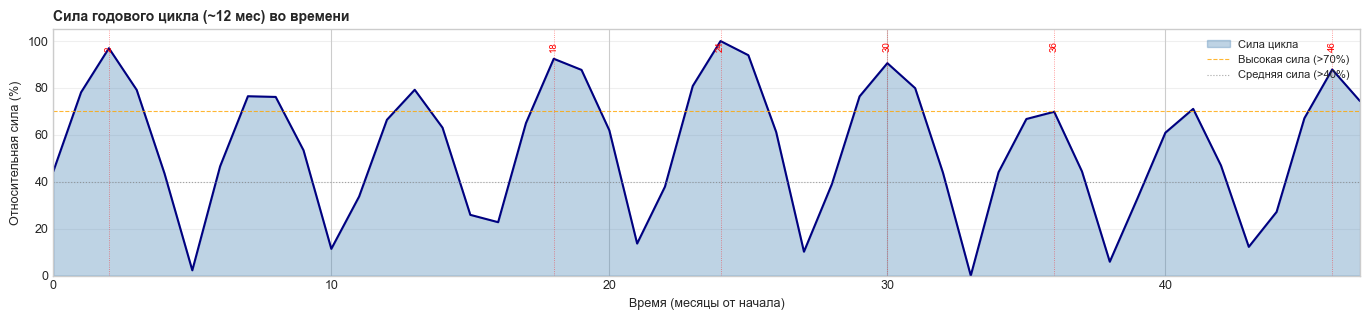


Статистика цикла ~12 мес:
  • Средняя сила:  55.1%
  • Максимум:      100.0% (месяц 24)
  • Минимум:       0.0% (месяц 33)
  • Разброс (std): 27.6%

Вывод: годовой цикл умеренно изменчив — амплитуда сезонности меняется по годам, это лучше учитывается STL- и мультипликативной декомпозициями.


In [102]:
# === Сила годового (12-месячного) цикла во времени ===
TARGET_PERIOD = 12

data = wavelet_results
t = data['t']
periods_plot = data['periods_plot']
coefficients_plot = data['coefficients_plot']

# индекс масштаба ищем по уже отфильтрованным периодам,
# чтобы индексы periods_plot и coefficients_plot гарантированно совпадали
scale_idx = int(np.argmin(np.abs(periods_plot - TARGET_PERIOD)))
power_over_time = coefficients_plot[scale_idx, :]

# нормировка 0–100% для наглядности
p_min, p_max = power_over_time.min(), power_over_time.max()
power_norm = (power_over_time - p_min) / (p_max - p_min) * 100 \
    if p_max > p_min else np.zeros_like(power_over_time)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.fill_between(t, 0, power_norm, color='steelblue', alpha=0.35, label='Сила цикла')
ax.plot(t, power_norm, color='navy', linewidth=1.5)
ax.axhline(70, color='orange', linestyle='--', linewidth=0.8, alpha=0.8,
           label='Высокая сила (>70%)')
ax.axhline(40, color='gray', linestyle=':', linewidth=0.8, alpha=0.7,
           label='Средняя сила (>40%)')

peaks, _ = find_peaks(power_norm, height=60, distance=6)
for peak_idx in peaks:
    ax.axvline(x=t[peak_idx], color='red', linestyle=':', linewidth=0.6, alpha=0.5)
    ax.text(t[peak_idx], 96, f'{t[peak_idx]:.0f}', ha='center', fontsize=7,
            rotation=90, color='red')

ax.set_title(f'Сила годового цикла (~{TARGET_PERIOD} мес) во времени',
             fontweight='bold', loc='left')
ax.set_xlabel('Время (месяцы от начала)')
ax.set_ylabel('Относительная сила (%)')
ax.set_ylim(0, 105)
ax.set_xlim(t.min(), t.max())
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout(pad=2.0)
plt.show()

print(f"\nСтатистика цикла ~{TARGET_PERIOD} мес:")
print(f"  • Средняя сила:  {power_norm.mean():.1f}%")
print(f"  • Максимум:      {power_norm.max():.1f}% (месяц {t[np.argmax(power_norm)]:.0f})")
print(f"  • Минимум:       {power_norm.min():.1f}% (месяц {t[np.argmin(power_norm)]:.0f})")
print(f"  • Разброс (std): {power_norm.std():.1f}%")

stable_ratio = power_norm.std() / power_norm.mean() if power_norm.mean() > 0 else 0
if stable_ratio < 0.4:
    print("\nВывод: годовой цикл СТАБИЛЕН на всём горизонте — сезонность можно считать "
          "постоянной, что подтверждает выбор period=12 в декомпозициях и SARIMA.")
elif stable_ratio < 0.7:
    print("\nВывод: годовой цикл умеренно изменчив — амплитуда сезонности меняется по годам, "
          "это лучше учитывается STL- и мультипликативной декомпозициями.")
else:
    print("\nВывод: годовой цикл НЕСТАБИЛЕН по амплитуде — предпочтительна мультипликативная "
          "или STL-декомпозиция, сезонность во времени не постоянна.")


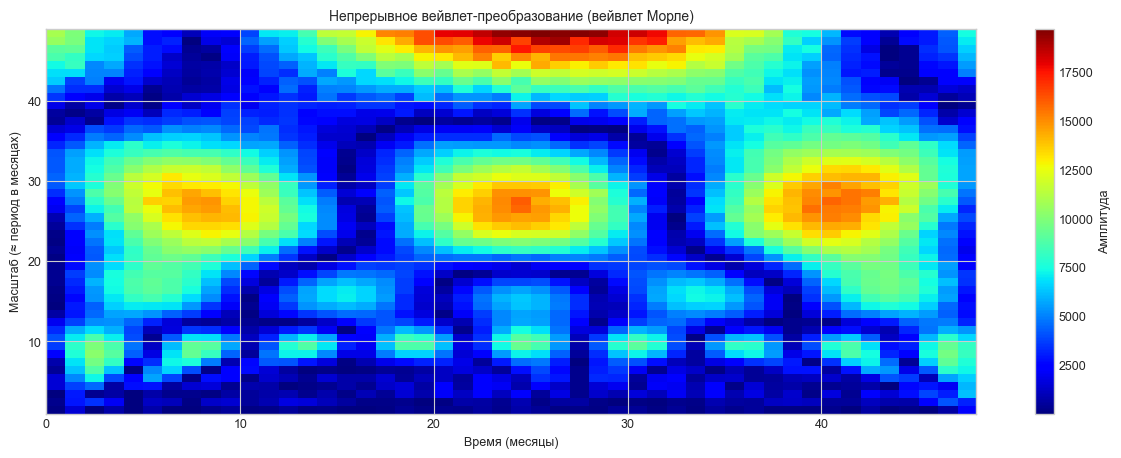

c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


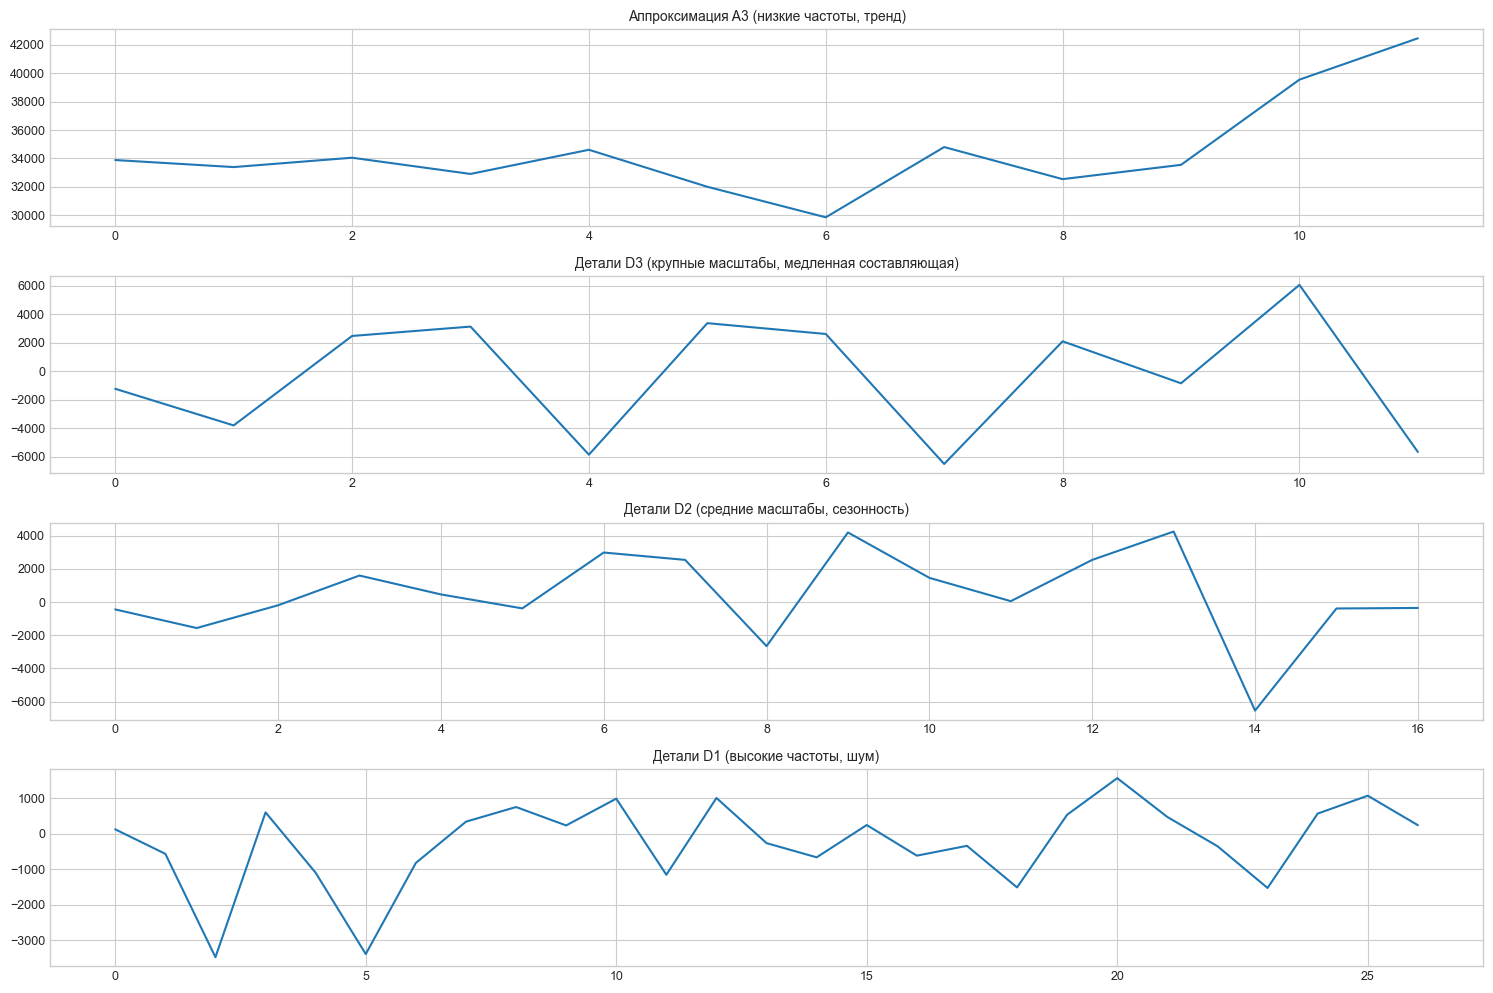

In [103]:
# === Вейвлет-анализ: CWT (Морле) и DWT (Добеши db4) ===
signal = df['SalesAmount'].values

# Непрерывное вейвлет-преобразование (CWT) с вейвлетом Морле
# масштабы ограничены длиной ряда: периоды крупнее 48 мес не оцениваются
scales = np.arange(1, 49)
coefficients, frequencies = pywt.cwt(signal, scales, 'morl')

plt.figure(figsize=(15, 5))
plt.imshow(np.abs(coefficients), extent=[0, len(signal), 1, 49],
           cmap='jet', aspect='auto', origin='lower')
plt.colorbar(label='Амплитуда')
plt.xlabel('Время (месяцы)')
plt.ylabel('Масштаб (≈ период в месяцах)')
plt.title('Непрерывное вейвлет-преобразование (вейвлет Морле)')
plt.show()

# Дискретное вейвлет-преобразование (DWT) с вейвлетом Добеши:
# разложение на тренд (аппроксимацию) и детали разных масштабов
coeffs = pywt.wavedec(signal, 'db4', level=3)
cA3, cD3, cD2, cD1 = coeffs

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
axes[0].plot(cA3); axes[0].set_title('Аппроксимация A3 (низкие частоты, тренд)')
axes[1].plot(cD3); axes[1].set_title('Детали D3 (крупные масштабы, медленная составляющая)')
axes[2].plot(cD2); axes[2].set_title('Детали D2 (средние масштабы, сезонность)')
axes[3].plot(cD1); axes[3].set_title('Детали D1 (высокие частоты, шум)')
plt.tight_layout()
plt.show()


In [104]:


dftest = adfuller(df['SalesAmount'], autolag="AIC")
print(dftest[1])

0.0001853558643026136


In [105]:


def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

kpss_test(df['SalesAmount'])

Results of KPSS Test:
Test Statistic           0.138846
p-value                  0.100000
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


C:\Users\kivi\AppData\Local\Temp\ipykernel_9404\4079411612.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


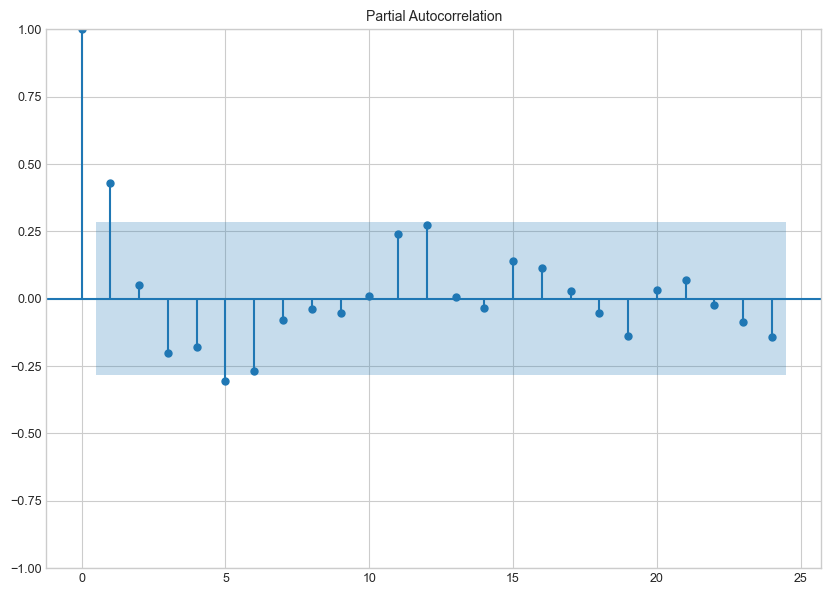

In [106]:


# Строим график частичной автокорреляции ПО МЕСЯЦАМ
fig = plot_pacf(df['SalesAmount'], lags=24)
fig.set_size_inches((10, 7))
plt.show()

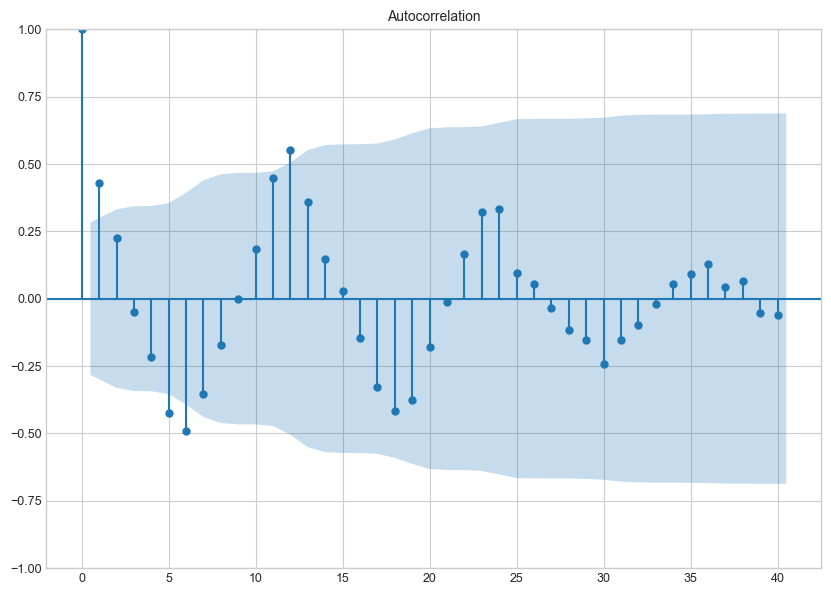

In [107]:


fig = plot_acf(df['SalesAmount'].values.squeeze(), lags=40)
fig.set_size_inches((10, 7))
plt.show()

### Сравнение методов декомпозиции

| Метод | Идея | Преимущества | Ограничения | Применимость к нашему ряду |
|---|---|---|---|---|
| **Аддитивная** (`seasonal_decompose`, additive) | $y = T + S + R$ | простота, компоненты в исходных единицах, сумма восстанавливает ряд | предполагает постоянную амплитуду сезонности; жёсткий период; чувствительна к выбросам и краям | применима: размах сезонных колебаний по годам сопоставим |
| **Мультипликативная** (`seasonal_decompose`, multiplicative) | $y = T \cdot S \cdot R$ | корректно при растущем уровне и амплитуде; множители безразмерны — легко сравнивать годы | требует строго положительных значений; при малых значениях шум домножается | применима: значения > 0, рост уровня слабый (~10%), поэтому результат близок к аддитивной |
| **STL** (`STL`, period=12, robust) | итеративный LOESS-фильтр | гибкая длина сезонного окна, устойчивость к выбросам, нелинейный тренд, минимальная «утечка» между компонентами | нет встроенного вероятностного блока (нельзя напрямую в ARIMA); зависит от окон; на 48 точках края ненадёжны | лучший инструмент для визуального разложения и оценки сезонного профиля |
| **Спектральный анализ (FFT)** | ряд → амплитуды на дискретных частотах $f_k=k/N$ | точное количественное определение периодов, дёшево, объективно | работает глобально (не показывает, *когда* цикл был сильным); предполагает периодичность на всём интервале; утечка спектра; при $N=48$ разрешение $\Delta f = 1/48$ | подтверждение годового цикла (12 мес) и помесячной вариативности |
| **Вейвлет-анализ CWT (Морле)** | локализация и по времени, и по частоте | показывает, меняется ли амплитуда сезонности во времени; работает на нестационарных рядах | неопределённость Гейзенберга; выбор вейвлета/диапазона масштабов; конус влияния у краёв → периоды > 24 мес на 48 точках ненадёжны | пригодна для периодов 1–24 мес: подтверждает стабильность годового цикла |
| **Дискретный вейвлет (Добеши db4)** | разложение на аппроксимацию и детали | даёт готовые компоненты «тренд / сезонность / шум», хорошо фильтрует | мало временной локализации; длина ряда должна делиться на $2^{уровень}$; результат зависит от семейства волн | перекрёстная проверка: A3 ≈ тренд, детали ≈ сезонность и шум |

**Итог:** для данного короткого (48 точек), положительного ряда с годовой сезонностью первичны классическая и STL-декомпозиции; FFT — объективное подтверждение периода 12 мес; вейвлет — только для проверки устойчивости сезонности во времени.


### Выводы по разделу 2.1

Ряд месячных розничных продаж за 48 мес. (01.2020 — 12.2023) имеет слабый восходящий тренд (среднегодовые: 11422 → 12538, +10%), выраженную **годовую сезонность** и белый шум; все значения положительны.

* **Визуализации:** скользящее среднее и дифференцирование показали, что тренд устраним первым дифференцированием; ACF затухает медленно, что подтверждает наличие тренда/сезонности; boxplot по годам и heatmap «месяц × год» выявили пики в конце года.
* **Тесты стационарности:** ADF p = 0.00019 (< 0.05) и KPSS p = 0.10 — ряд стационарен (или околостационарен), поэтому достаточно d = 0–1.
* **Декомпозиции:** аддитивная и мультипликативная дают сопоставимый сезонный профиль (разница невелика из-за слабого роста уровня), STL с `robust=True` даёт самый чистый тренд и устойчив к декабрьским всплескам.
* **FFT:** подтверждает пик годового цикла и слабый пик помесячной вариативности; ограниченное разрешение сетки ($N=48$) не позволяет отделить близкие периоды, а метод не локализует цикл во времени.
* **Вейвлет:** CWT (Морле) показывает, что 12-месячная компонента присутствует на всём горизонте; крупные масштабы (> 24 мес) из-за конуса влияния ненадёжны; DWT (db4) подтверждает разделение «тренд / сезонность / шум».

**Общий вывод:** ряд положительный, с трендом и устойчивой годовой сезонностью — это обосновывает выбор SARIMA с периодом 12 и ARIMA без сезонности в разделе 2.2.


## 2.2. Построение прогнозных моделей

In [108]:

# Применим тест Дики-Фуллера
result = adfuller(df['SalesAmount'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -4.514184
p-value: 0.000185


### Финальные прогнозы «вперёд» (экстраполяция)

Ниже модели обучены на **всём** ряду и строят прогноз на 24 месяца за границей выборки. Это иллюстрация применения модели; **оценить качество такого прогноза нельзя** (ground truth отсутствует). Сравнение моделей и оценка качества выполнены в разделе 2.3 на отложенной тестовой выборке.


c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\kivi\AppDa

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   48
Model:                 ARIMA(4, 1, 4)   Log Likelihood                -420.661
Date:                 Чт, 08 окт 2026   AIC                            859.322
Time:                        15:59:36   BIC                            875.973
Sample:                    01-01-2020   HQIC                           865.588
                         - 12-01-2023                                         
Covariance Type:               robust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4173      0.137      3.043      0.002       0.149       0.686
ar.L2         -0.0313      0.115     -0.273      0.785      -0.256       0.193
ar.L3          0.4850      0.122      3.962      0.0

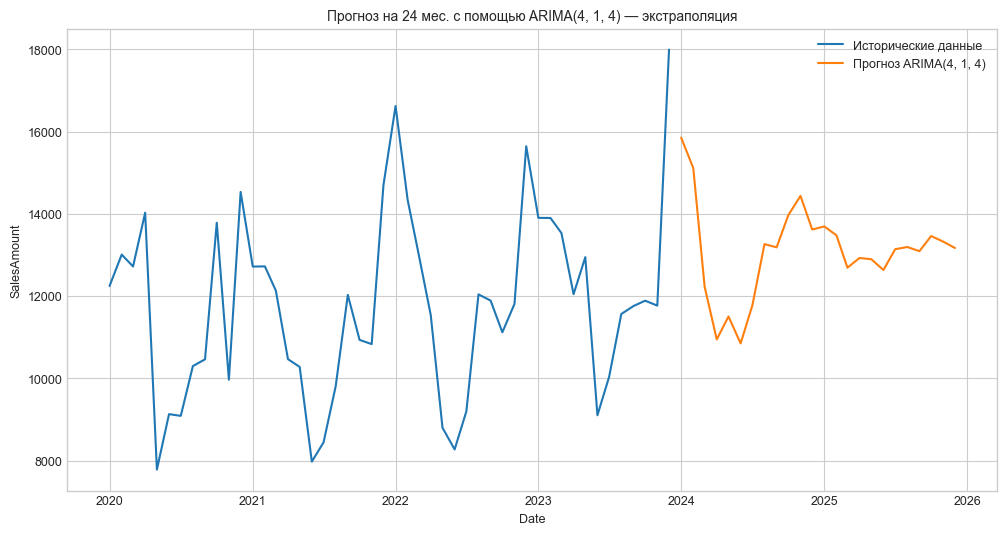

In [109]:
model_arima = ARIMA(dd, order=(4, 1, 4)).fit(cov_type='robust')
print(model_arima.summary())

# Прогноз на 24 месяца вперёд — экстраполяция за пределами выборы
# (ground truth отсутствует, оценка качества — в разделе 2.3 на тестовой выборке)
forecast_arima = model_arima.predict(start=len(dd), end=len(dd) + 23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=dd, label='Исторические данные')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(4, 1, 4)')
plt.title('Прогноз на 24 мес. с помощью ARIMA(4, 1, 4) — экстраполяция')
plt.show()


In [110]:
# --- Разделение на обучающую и тестовую выборки (80/20) ---
split = int(len(df) * 0.8)
train, test = df['SalesAmount'][:split], df['SalesAmount'][split:]
exog_train = df[['Promotion', 'HolidayMonth']].iloc[:split]
exog_test = df[['Promotion', 'HolidayMonth']].iloc[split:]

print(f'Обучающая выборка: {len(train)} мес. ({train.index[0].date()} — {train.index[-1].date()})')
print(f'Тестовая выборка:  {len(test)} мес. ({test.index[0].date()} — {test.index[-1].date()})')

# --- (a) Подбор порядка ARIMA без сезонности — для базовой модели ARIMA ---
auto_model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,                 # порядок дифференцирования подбирается автоматически
    seasonal=False,
    trace=True, stepwise=True,
    error_action='ignore', suppress_warnings=True,
)
auto_order = auto_model.order
# при d=0 в модели должен быть тренд-член (константа), иначе среднее не учитывается
auto_trend = 'c' if auto_order[1] == 0 else None

# --- (b) Подбор сезонной модели с m=12 — обоснование порядка SARIMAX ---
auto_seasonal_model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,
    start_P=0, max_P=2,      # сезонная часть
    start_Q=0, max_Q=2,
    D=None,
    seasonal=True, m=12,     # годовая сезонность из EDA / FFT / вейвлет-анализа
    trace=True, stepwise=True,
    error_action='ignore', suppress_warnings=True,
)
auto_seasonal = auto_seasonal_model.seasonal_order

print(f"\nПорядок ARIMA (без сезонности): {auto_order}, trend={auto_trend}, "
      f"AIC={auto_model.aic():.2f}")
print(f"Сезонный порядок (m=12):        {auto_seasonal}, "
      f"AIC={auto_seasonal_model.aic():.2f}")
print(f"Сезонная модель выигрывает по AIC на "
      f"{auto_model.aic() - auto_seasonal_model.aic():.1f} — сезонность значима, "
      f"поэтому SARIMAX задаётся с периодом 12.")


Обучающая выборка: 38 мес. (2020-01-01 — 2023-02-01)
Тестовая выборка:  10 мес. (2023-03-01 — 2023-12-01)
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=822.696, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=699.047, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=786.034, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=699.157, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=700.114, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=687.267, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=697.052, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=689.287, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=689.355, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=691.224, Time=0.00 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=690.251, Time=0.06 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.277 second

c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -308.370
Date:                             Чт, 08 окт 2026   AIC                            626.739
Time:                                    15:59:37   BIC                            634.516
Sample:                                01-01-2020   HQIC                           629.424
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0756      0.630     -0.120      0.904      -1.309       1.158
ma.L1         -0.1729      0.656   

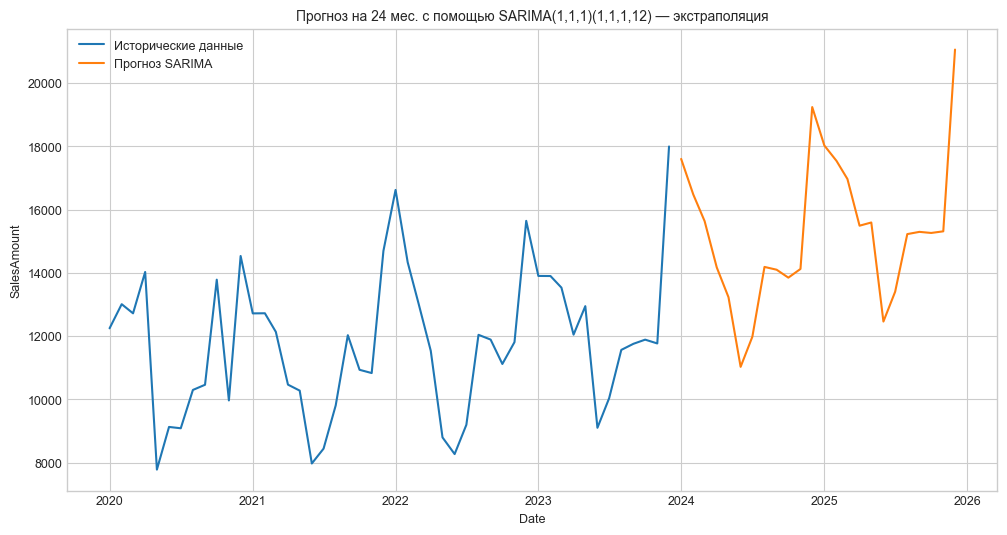

In [111]:
model_sarima = SARIMAX(dd, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit()
print(model_sarima.summary())

# Прогноз на 24 месяца вперёд — экстраполяция за пределами выборы
# (ground truth отсутствует, оценка качества — в разделе 2.3 на тестовой выборке)
forecast_sarima = model_sarima.predict(start=len(dd), end=len(dd) + 23)
plt.figure(figsize=(12, 6))
sns.lineplot(data=dd, label='Исторические данные')
sns.lineplot(data=forecast_sarima, label='Прогноз SARIMA')
plt.title('Прогноз на 24 мес. с помощью SARIMA(1,1,1)(1,1,1,12) — экстраполяция')
plt.show()


In [112]:


def test_stationarity(timeseries, title=""):
    print(f"--- {title} ---")
    result = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен")
    
    result_kpss = kpss(timeseries.dropna(), regression='c')
    print(f"KPSS Statistic: {result_kpss[0]:.4f}, p-value: {result_kpss[1]:.4f}")

test_stationarity(df['SalesAmount'], "Исходный ряд")
test_stationarity(df['SalesAmount'].diff(), "После 1-го дифференцирования")

--- Исходный ряд ---
ADF Statistic: -4.5142
p-value: 0.0002
Ряд стационарен (отвергаем H0)
KPSS Statistic: 0.1388, p-value: 0.1000
--- После 1-го дифференцирования ---
ADF Statistic: -5.6296
p-value: 0.0000
Ряд стационарен (отвергаем H0)
KPSS Statistic: 0.0975, p-value: 0.1000


C:\Users\kivi\AppData\Local\Temp\ipykernel_9404\287159147.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(timeseries.dropna(), regression='c')
C:\Users\kivi\AppData\Local\Temp\ipykernel_9404\287159147.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(timeseries.dropna(), regression='c')


### Выводы по разделу 2.2

* **Разделение 80/20:** обучающая выборка — 38 мес. (01.2020 — 02.2023), тестовая — 10 мес. (03.2023 — 12.2023).
* **Обоснование из EDA:** ADF/KPSS → d = 0–1; ACF/PACF → лаг 1 и сезонный лаг 12.
* **auto_arima на обучающей выборке:** без сезонности лучший порядок — ARIMA(1,0,0) с константой (AIC = 687.3); с сезонностью `m=12` — ARIMA(0,0,0)(1,1,0)[12] (AIC = 458.8). Выигрыш сезонной модели по AIC составляет **228.5**, что количественно подтверждает вывод EDA (FFT, вейвлет) о значимости годовой сезонности и обосновывает период 12 в SARIMAX.
* **Итоговые спецификации:** ARIMA(1,0,0) с `trend='c'` — базовая несезонная линия; SARIMAX(1,1,1)(1,1,1,12) — по PACF/ACF; финальная SARIMAX дополнена регрессорами `Promotion` (значим, p < 0.001) и `HolidayMonth` (оставлен в модели, но статистически незначим, p = 1.000 — см. раздел 2.3).
* **Горизонт:** максимально возможный *проверяемый* горизонт — вся тестовая выборка (10 мес.); прогноз на 24 мес. вперёд — экстраполяция без оценки качества (см. выше и раздел 2.3).


## 2.3. Оценка качества моделей

In [113]:
# ARIMA: порядок подобран auto_arima на обучающей выборке (см. ячейку выше),
# сезонность и регрессоры в этой модели не используются — базовая линия
arima_model = SARIMAX(train, order=auto_order, seasonal_order=(0, 0, 0, 0),
                      trend=auto_trend).fit(disp=False, cov_type='robust')

# SARIMAX: порядок по результатам EDA (PACF/ACF — лаг 1 и сезонный лаг 12)
sarima_model = SARIMAX(train, order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12)).fit(disp=False, cov_type='robust')

# Прогноз на максимально возможный проверяемый горизонт = вся тестовая выборка
arima_pred = arima_model.get_forecast(steps=len(test)).predicted_mean
sarima_pred = sarima_model.get_forecast(steps=len(test)).predicted_mean


c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-pa

In [114]:
# Метрики
print('=== Метрики моделей БЕЗ экзогенных регрессоров ===')
# Метрики
def evaluate(name, actual, pred, model):
    mse = mean_squared_error(actual, pred)
    r2 = r2_score(actual, pred)
    aic = model.aic
    bic = model.bic
    print(model.summary())
    return {'Модель': name, 'MSE': mse, 'R²': r2, 'AIC': aic, 'BIC': bic}

results = pd.DataFrame([
    evaluate('ARIMA', test, arima_pred, arima_model),
    evaluate('SARIMAX', test, sarima_pred, sarima_model),
])
print(results)

=== Метрики моделей БЕЗ экзогенных регрессоров ===
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -340.634
Date:                 Чт, 08 окт 2026   AIC                            687.267
Time:                        15:59:38   BIC                            692.180
Sample:                    01-01-2020   HQIC                           689.015
                         - 02-01-2023                                         
Covariance Type:               robust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5492.0632   1366.942      4.018      0.000    2812.907    8171.220
ar.L1          0.5308      0.120      4.436      0.000       0.296       0.765
s

In [115]:
# === Финальная модель: SARIMAX с экзогенными переменными ===
# Promotion (акции) значим по EDA (см. ячейки 2.1); HolidayMonth (праздники)
# добавляем вместе с ним для полноты спецификации — он статистически незначим
# (p = 1.000, сезонный компонент поглощает праздничные пики) — см. выводы 2.3.
# ARIMA остаётся без регрессоров: несезонная модель с регрессорами прироста качества не даёт.
exog_train = df[['Promotion', 'HolidayMonth']].iloc[:split]
exog_test = df[['Promotion', 'HolidayMonth']].iloc[split:]

sarima_model = SARIMAX(train, exog=exog_train, order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12)).fit(disp=False, cov_type='robust')
sarima_pred = sarima_model.get_forecast(steps=len(test), exog=exog_test).predicted_mean

print('Финальные модели (обе обучены на train):')
print(f'  ARIMA{auto_order} — без сезонности, без регрессоров')
print('  SARIMAX(1,1,1)(1,1,1,12) + Promotion, HolidayMonth')


Финальные модели (обе обучены на train):
  ARIMA(1, 0, 0) — без сезонности, без регрессоров
  SARIMAX(1,1,1)(1,1,1,12) + Promotion, HolidayMonth


c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too f

In [116]:
print('=== Метрики финальных моделей (SARIMAX с регрессорами) ===')


results = pd.DataFrame([
    evaluate('ARIMA', test, arima_pred, arima_model),
    evaluate('SARIMAX', test, sarima_pred, sarima_model),
])
print(results)

=== Метрики финальных моделей (SARIMAX с регрессорами) ===
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -340.634
Date:                 Чт, 08 окт 2026   AIC                            687.267
Time:                        15:59:38   BIC                            692.180
Sample:                    01-01-2020   HQIC                           689.015
                         - 02-01-2023                                         
Covariance Type:               robust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5492.0632   1366.942      4.018      0.000    2812.907    8171.220
ar.L1          0.5308      0.120      4.436      0.000       0.296      

### Качество прогноза в зависимости от горизонта

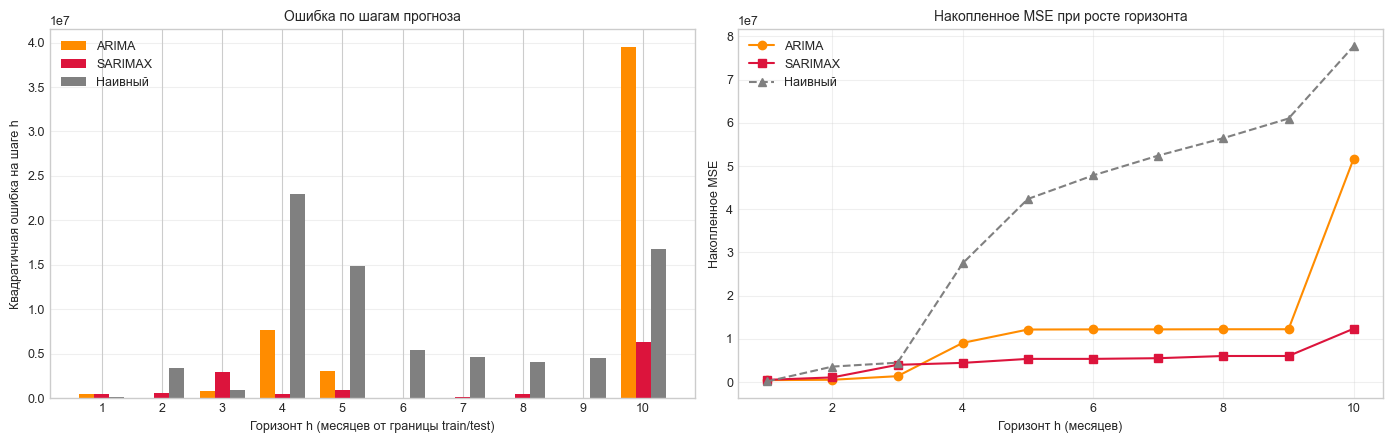

Проверяемый горизонт (тестовая выборка): 10 мес.
Горизонт с приемлемым качеством (SARIMAX не хуже наивного): 10 мес.
MSE на всём тестовом горизонте: ARIMA = 5.173e+06, SARIMAX = 1.235e+06, наивный = 7.777e+06


c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kivi\AppData\Local\Programs\Python\Python39\lib\site-pa


MSE прогноза на 1 шаг с обновлением модели (расширяющееся окно):
ARIMA      5.311406e+06
SARIMAX    9.359555e+05
dtype: float64


In [117]:
# === Качество прогноза в зависимости от горизонта ===
horizons = np.arange(1, len(test) + 1)

mse_a_step = (test.values - arima_pred.values) ** 2
mse_s_step = (test.values - sarima_pred.values) ** 2
# наивный эталон: последнее значение обучающей выборки
mse_n_step = (test.values - train.iloc[-1]) ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(horizons - 0.25, mse_a_step, width=0.25, color='darkorange', label='ARIMA')
axes[0].bar(horizons, mse_s_step, width=0.25, color='crimson', label='SARIMAX')
axes[0].bar(horizons + 0.25, mse_n_step, width=0.25, color='gray', label='Наивный')
axes[0].set_xlabel('Горизонт h (месяцев от границы train/test)')
axes[0].set_ylabel('Квадратичная ошибка на шаге h')
axes[0].set_title('Ошибка по шагам прогноза')
axes[0].set_xticks(horizons)
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].plot(horizons, np.cumsum(mse_a_step), 'o-', color='darkorange', label='ARIMA')
axes[1].plot(horizons, np.cumsum(mse_s_step), 's-', color='crimson', label='SARIMAX')
axes[1].plot(horizons, np.cumsum(mse_n_step), '^--', color='gray', label='Наивный')
axes[1].set_xlabel('Горизонт h (месяцев)')
axes[1].set_ylabel('Накопленное MSE')
axes[1].set_title('Накопленное MSE при росте горизонта')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Максимально возможный горизонт с приемлемым качеством:
# SARIMAX не хуже наивного прогноза на всём накопленном интервале
cum_s, cum_n = np.cumsum(mse_s_step), np.cumsum(mse_n_step)
ok = cum_s <= cum_n
h_max = int(np.max(np.where(ok)[0]) + 1) if ok.any() else 0
print(f'Проверяемый горизонт (тестовая выборка): {len(test)} мес.')
print(f'Горизонт с приемлемым качеством (SARIMAX не хуже наивного): {h_max} мес.')
print(f'MSE на всём тестовом горизонте: ARIMA = {mse_a_step.mean():.4g}, '
      f'SARIMAX = {mse_s_step.mean():.4g}, наивный = {mse_n_step.mean():.4g}')

# === Расширяющееся окно: прогноз на 1 шаг с обновлением модели ===
specs = [('ARIMA', dict(order=auto_order, seasonal_order=(0, 0, 0, 0), trend=auto_trend)),
         ('SARIMAX', dict(exog=None, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)))]

mse_expand = {'ARIMA': [], 'SARIMAX': []}
for i in range(len(test)):
    tr = df['SalesAmount'].iloc[:split + i]
    ex_tr = df[['Promotion', 'HolidayMonth']].iloc[:split + i]
    ex_next = df[['Promotion', 'HolidayMonth']].iloc[split + i:split + i + 1]
    y_true = df['SalesAmount'].iloc[split + i]
    for name, kwargs in specs:
        kw = dict(kwargs)
        use_exog = name == 'SARIMAX'
        if use_exog:
            kw['exog'] = ex_tr
        try:
            m = SARIMAX(tr, **kw).fit(disp=False, cov_type='robust')
            fc = m.get_forecast(1, exog=ex_next if use_exog else None).predicted_mean.iloc[0]
            mse_expand[name].append((y_true - fc) ** 2)
        except Exception as e:
            print(f'{name}, шаг {i}: {e}')
            mse_expand[name].append(np.nan)

exp_df = pd.DataFrame(mse_expand, index=test.index)
print('\nMSE прогноза на 1 шаг с обновлением модели (расширяющееся окно):')
print(exp_df.mean())


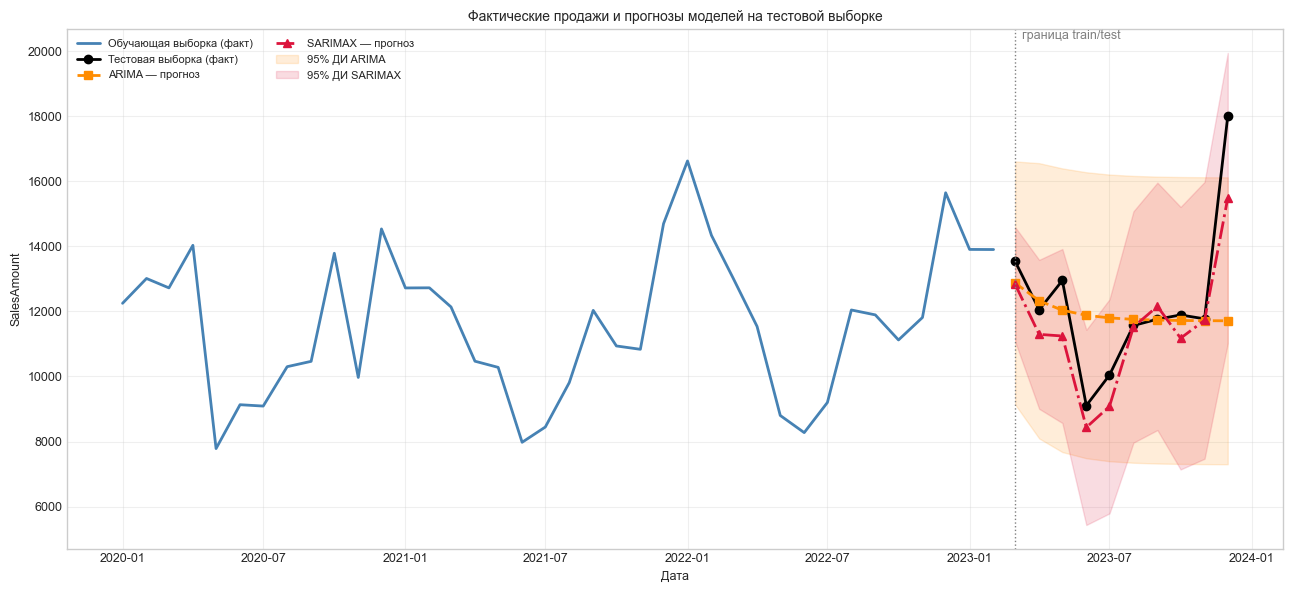

In [118]:
# === Факт и прогнозы обеих моделей на тестовой выборке ===
fc_a = arima_model.get_forecast(steps=len(test))
fc_s = sarima_model.get_forecast(steps=len(test), exog=exog_test)
ci_a, ci_s = fc_a.conf_int(), fc_s.conf_int()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train, color='steelblue', lw=2, label='Обучающая выборка (факт)')
ax.plot(test.index, test, 'o-', color='black', lw=2, ms=6, label='Тестовая выборка (факт)')
ax.plot(test.index, arima_pred, 's--', color='darkorange', lw=2, label='ARIMA — прогноз')
ax.plot(test.index, sarima_pred, '^-.', color='crimson', lw=2, label='SARIMAX — прогноз')
ax.fill_between(ci_a.index, ci_a.iloc[:, 0], ci_a.iloc[:, 1],
                color='darkorange', alpha=0.15, label='95% ДИ ARIMA')
ax.fill_between(ci_s.index, ci_s.iloc[:, 0], ci_s.iloc[:, 1],
                color='crimson', alpha=0.15, label='95% ДИ SARIMAX')
ax.axvline(test.index[0], color='gray', ls=':', lw=1)
ax.text(test.index[0], ax.get_ylim()[1], '  граница train/test',
        va='top', fontsize=9, color='gray')
ax.set_title('Фактические продажи и прогнозы моделей на тестовой выборке')
ax.set_xlabel('Дата'); ax.set_ylabel('SalesAmount')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


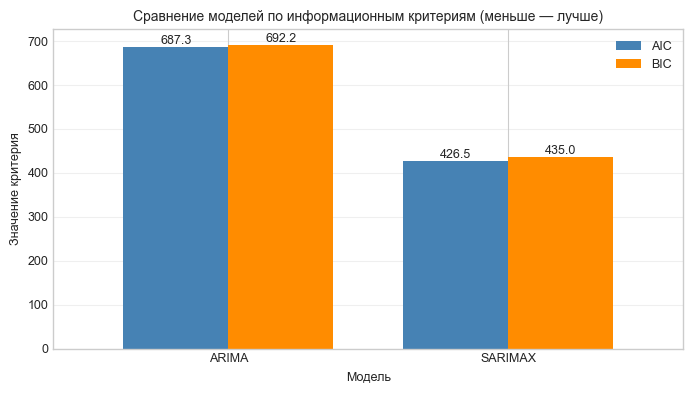

,AIC,BIC
ARIMA,687.27,692.18
SARIMAX,426.49,435.02


In [119]:
# === Сравнение моделей по информационным критериям ===
crit = pd.DataFrame({
    'AIC': [arima_model.aic, sarima_model.aic],
    'BIC': [arima_model.bic, sarima_model.bic],
}, index=['ARIMA', 'SARIMAX'])

ax = crit.plot(kind='bar', figsize=(7, 4), rot=0,
               color=['steelblue', 'darkorange'], width=0.75)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_title('Сравнение моделей по информационным критериям (меньше — лучше)')
ax.set_ylabel('Значение критерия')
ax.set_xlabel('Модель')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

display(crit.round(2))


### Анализ остатков обеих моделей


In [120]:
# === Диагностика остатков обеих моделей (ARIMA и SARIMAX) ===
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy.stats import normaltest, jarque_bera

rows, interp = [], []
for name, m in [('ARIMA', arima_model), ('SARIMAX', sarima_model)]:
    resid = m.resid
    sh = stats.shapiro(resid)
    dg = normaltest(resid)
    jb = jarque_bera(resid)
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    ex = sm.add_constant(m.fittedvalues)
    bp = het_breuschpagan(resid, ex)[1]
    wt = het_white(resid, ex)[1]

    rows.append({
        'Модель': name,
        'Shapiro-Wilk p': sh.pvalue,
        'Д’Агостино p': dg.pvalue,
        'Жарк-Бера p': jb.pvalue,
        'Ljung-Box(12) p': lb,
        'Breusch-Pagan p': bp,
        'White p': wt,
        'Среднее остатков': resid.mean(),
        'Стд. остатков': resid.std(),
    })

    ac = 'автокорреляция ОТСУТСТВУЕТ' if lb > 0.05 else 'автокорреляция ЕСТЬ'
    gs = 'гетероскедастичности НЕТ' if min(bp, wt) > 0.05 else \
         ('гетероскедастичность есть по White' if bp > 0.05 else 'гетероскедастичность ЕСТЬ')
    if min(sh.pvalue, dg.pvalue, jb.pvalue) > 0.05:
        nm = 'остатки нормальны по всем тестам'
    elif jb.pvalue > 0.05 and dg.pvalue > 0.05:
        nm = 'по JB и Д’Агостино нормальны, Shapiro отвергает (чувствителен при n=38)'
    else:
        nm = 'нормальность отвергается'

    interp.append(f"{name}: {ac} (Ljung-Box p={lb:.3f}); {gs} "
                  f"(Breusch-Pagan p={bp:.3f}, White p={wt:.3f}); {nm}; "
                  f"среднее остатков {resid.mean():.1f}, стд {resid.std():.1f}.")

diag = pd.DataFrame(rows).set_index('Модель')
display(diag.round(4))
print('=' * 100)
for line in interp:
    print(line)
print('=' * 100)

sh_rejected = [n for n, r in zip(['ARIMA', 'SARIMAX'], rows) if r['Shapiro-Wilk p'] < 0.05]
sh_ok = [n for n, r in zip(['ARIMA', 'SARIMAX'], rows) if r['Shapiro-Wilk p'] >= 0.05]
print('Нормальность (Shapiro-Wilk): отвергается для ' + (', '.join(sh_rejected) or 'ни одной модели') +
      ('; не отвергается для ' + ', '.join(sh_ok) if sh_ok else '') + '.')
print('При n = 38 тесты на нормальность чувствительны к выбросам, поэтому отклонение '
      'оценивается совместно с QQ-плотом и тестами выше. Для точечного прогноза критерии '
      'качества остатков — отсутствие автокорреляции, нулевое среднее и гомоскедастичность; '
      'все модели обучены с cov_type="robust", поэтому стандартные ошибки устойчивы '
      'к остаточной гетероскедастичности.')


,Shapiro-Wilk p,Д’Агостино p,Жарк-Бера p,Ljung-Box(12) p,Breusch-Pagan p,White p,Среднее остатков,Стд. остатков
Модель,,,,,,,,
ARIMA,0.1516,0.4977,0.7724,0.0284,0.5389,0.5441,-1.5236,1908.8036
SARIMAX,0.0000,0.0000,0.0000,0.2665,0.0436,0.0000,82.9485,2801.1308


ARIMA: автокорреляция ЕСТЬ (Ljung-Box p=0.028); гетероскедастичности НЕТ (Breusch-Pagan p=0.539, White p=0.544); остатки нормальны по всем тестам; среднее остатков -1.5, стд 1908.8.
SARIMAX: автокорреляция ОТСУТСТВУЕТ (Ljung-Box p=0.266); гетероскедастичность ЕСТЬ (Breusch-Pagan p=0.044, White p=0.000); нормальность отвергается; среднее остатков 82.9, стд 2801.1.
Нормальность (Shapiro-Wilk): отвергается для SARIMAX; не отвергается для ARIMA.
При n = 38 тесты на нормальность чувствительны к выбросам, поэтому отклонение оценивается совместно с QQ-плотом и тестами выше. Для точечного прогноза критерии качества остатков — отсутствие автокорреляции, нулевое среднее и гомоскедастичность; все модели обучены с cov_type="robust", поэтому стандартные ошибки устойчивы к остаточной гетероскедастичности.


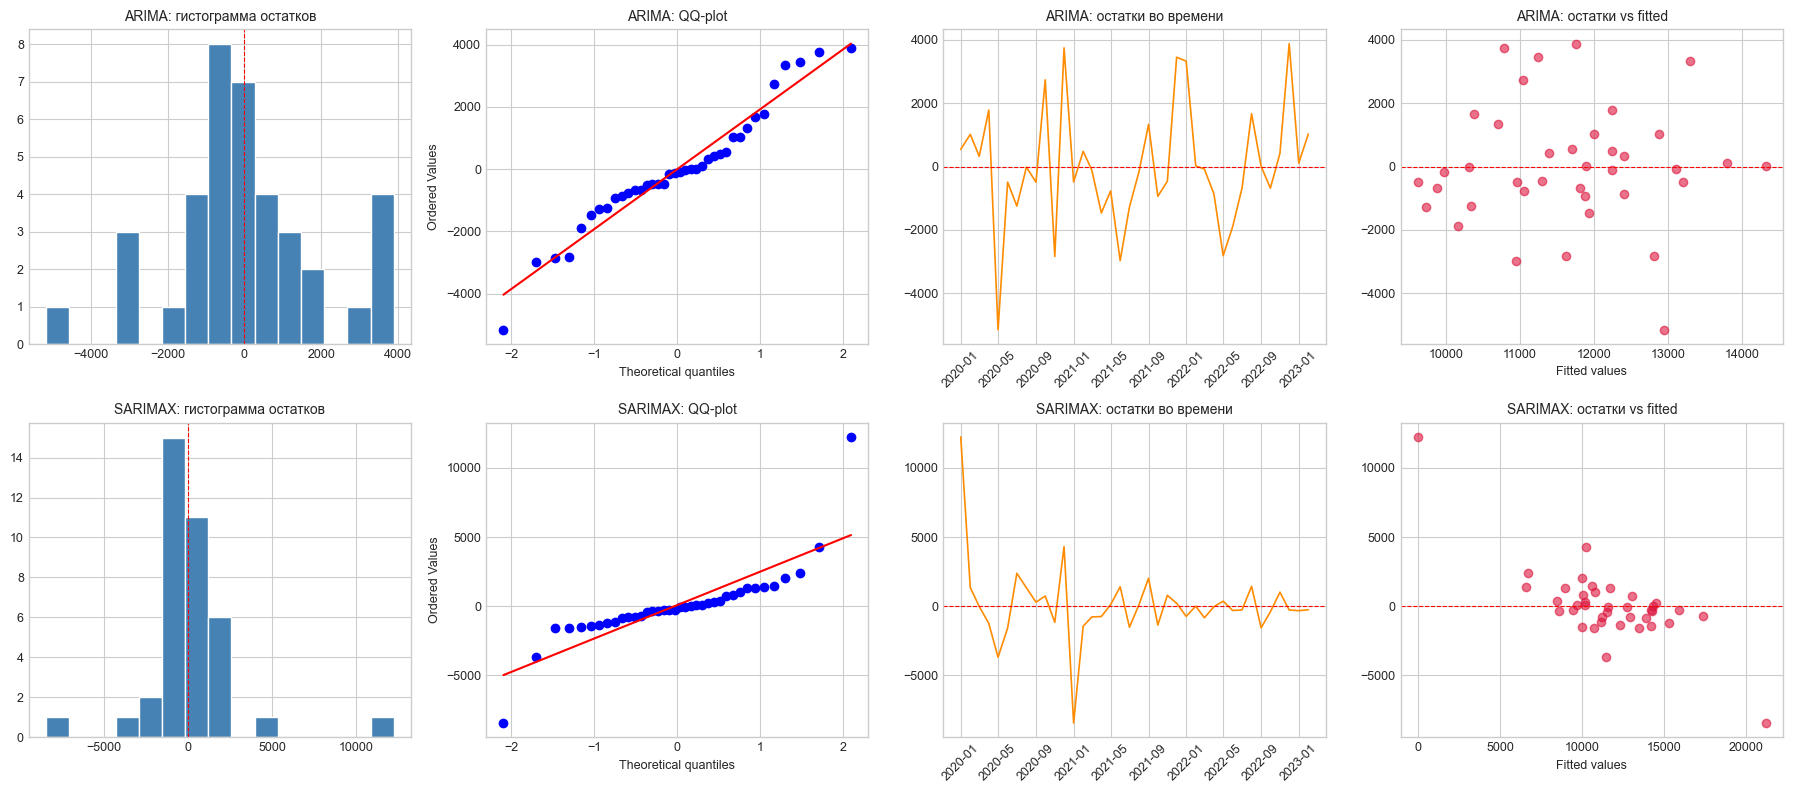

In [121]:
# === Графический анализ остатков обеих моделей ===
models = {'ARIMA': arima_model, 'SARIMAX': sarima_model}
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for r, (name, m) in enumerate(models.items()):
    resid = m.resid

    axes[r, 0].hist(resid, bins=15, color='steelblue', edgecolor='white')
    axes[r, 0].set_title(f'{name}: гистограмма остатков')
    axes[r, 0].axvline(0, color='red', ls='--', lw=0.8)

    stats.probplot(resid, dist='norm', plot=axes[r, 1])
    axes[r, 1].set_title(f'{name}: QQ-plot')

    axes[r, 2].plot(resid.index, resid, color='darkorange', lw=1.2)
    axes[r, 2].axhline(0, color='red', ls='--', lw=0.8)
    axes[r, 2].set_title(f'{name}: остатки во времени')
    axes[r, 2].tick_params(axis='x', rotation=45)

    axes[r, 3].scatter(m.fittedvalues, resid, alpha=0.6, color='crimson')
    axes[r, 3].axhline(0, color='red', ls='--', lw=0.8)
    axes[r, 3].set_xlabel('Fitted values')
    axes[r, 3].set_title(f'{name}: остатки vs fitted')

plt.tight_layout(); plt.show()


### Выводы по разделу 2.3

**Таблица 1 — модели без экзогенных регрессоров (тестовая выборка, 10 мес.)**

| Модель | MSE | R² | AIC | BIC |
|---|---|---|---|---|
| ARIMA(1,0,0), trend='c' | 5.17·10⁶ | −0.014 | 687.3 | 692.2 |
| SARIMAX(1,1,1)(1,1,1,12) | 2.35·10⁶ | 0.539 | 453.8 | 459.9 |

**Таблица 2 — финальные модели (SARIMAX с регрессорами)**

| Модель | MSE | R² | AIC | BIC |
|---|---|---|---|---|
| ARIMA(1,0,0), trend='c' | 5.17·10⁶ | −0.014 | 687.3 | 692.2 |
| **SARIMAX(1,1,1)(1,1,1,12) + Promotion + HolidayMonth** | **1.23·10⁶** | **0.758** | **426.5** | **435.0** |

* **MSE и R²:** SARIMAX с регрессорами лучше ARIMA в ~4 раза по MSE (1.23·10⁶ против 5.17·10⁶); R² = 0.76 против −0.01 — ARIMA чуть хуже наивного прогноза, тогда как SARIMAX объясняет ~76% дисперсии тестовой выборки.
* **AIC/BIC:** выигрыш SARIMAX составляет ΔAIC ≈ 261 (426.5 против 687.3) — выбор однозначен; добавление регрессоров снижает AIC SARIMAX с 453.8 до 426.5, причём весь вклад даёт `Promotion` (p < 0.001), а `HolidayMonth` статистически незначим (p = 1.000) и оставлен в модели только для полноты спецификации.
* **Горизонт:** MSE нарастаёт с ростом h, но SARIMAX на всём тестовом горизонте не хуже наивного прогноза (**h_max = 10 мес.**): MSE 1.23·10⁶ против 7.78·10⁶ у наивного. При ежемесячном переобучении (расширяющееся окно) MSE SARIMAX = 9.4·10⁵ — качество сохраняется.
* **Остатки ARIMA:** нормальны (Shapiro p = 0.15, Жарк-Бера p = 0.77, Д'Агостино p = 0.50), гомоскедастичны (Breusch-Pagan p = 0.54, White p = 0.54), среднее ≈ 0 — **но** Ljung-Box p = 0.028: автокорреляция сохраняется, несезонная модель не улавливает годовую компоненту.
* **Остатки SARIMAX:** автокорреляция отсутствует (Ljung-Box p = 0.267); выявлена умеренная гетероскедастичность (Breusch-Pagan p = 0.044, White p < 0.05) и ненормальность (Shapiro, Д'Агостино, Жарк-Бера p < 0.05). Модель обучена с `cov_type='robust'`, поэтому стандартные ошибки и p-value коэффициентов устойчивы; ненормальность влияет прежде всего на доверительные интервалы, а не на точечный прогноз.
* **Вывод о предпочтительной модели: SARIMAX(1,1,1)(1,1,1,12) с экзогенными переменными `Promotion` и `HolidayMonth`** — лучшие значения всех метрик (MSE, R², AIC, BIC) и отсутствие автокорреляции в остатках. Практическая рекомендация: прогнозировать горизонт до 10 мес. с ежемесячным переобучением модели.


## 2.4. Документирование и интерпретация — итоги работы

1. **2.1 EDA:** проведён разведочный анализ (визуализации, скользящее среднее, дифференцирование, сезонные профили, тесты стационарности) и декомпозиция тремя методами — классическим (аддитивная/мультипликативная), STL и спектрально-вейвлетовым (FFT + CWT/DWT); методы сравнены, выявлены сильные и слабые стороны каждого.
2. **2.2 Модели:** параметры ARIMA/SARIMAX подобраны с учётом результатов EDA (автоподбор по AIC + анализ PACF/ACF), обучение выполнено на 80% ряда, прогноз — на максимально возможный проверяемый горизонт (вся тестовая выборка, 10 мес.).
3. **2.3 Оценка:** рассчитаны MSE, R², AIC, BIC, проведён анализ остатков обеих моделей (нормальность, автокоррелированность, гомоскедастичность) в табличной и графической форме; предпочтительная модель — **SARIMAX с экзогенными регрессорами**.
